# Comparisons — NN V1 vs NN V2 vs NN V3

This notebook aggregates the training **histories** and test **metrics** exported by the three training notebooks: `outputs/NN_V1/*` `outputs/NN_V2/*`  `outputs/NN_V3/*`

It generates journal-ready figures: - Validation **accuracy** (three curves on one plot) - Validation **loss** (three curves on one plot)

It also builds: - A comparative **metrics table** (macro precision/recall/F1; support) → CSV - Per-model **confusion matrices** → PNG


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Matplotlib defaults: clean & readable (no specific colors)
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "font.size": 12
})


In [2]:
# === Configuration ===
MODELS = ["NN_V1", "NN_V2", "NN_V3"]      # dossiers exportés par tes 3 notebooks
BASE = Path("outputs")                     # racine des exports
FIGS = Path("figs")                        # dossier où on sauvegarde les figures comparatives
FIGS.mkdir(exist_ok=True)

# Noms des fichiers générés par la cellule EXPORT de chaque notebook
HIST_FILE     = "history.npz"
CLFREP_FILE   = "classification_report.json"
CM_FILE       = "confusion_matrix.csv"
RUNINFO_FILE  = "runinfo.json"             # optionnel, si généré


In [3]:
def load_history(model_name: str):
    """Load normalized training history from outputs/<model>/history.npz"""
    f = BASE / model_name / HIST_FILE
    if not f.exists():
        raise FileNotFoundError(f"Missing {f} — run the training notebook for {model_name} and export artifacts.")
    h = np.load(f, allow_pickle=True)
    # Keys normalized by export cells: accuracy, val_accuracy, loss, val_loss
    hist = {k: h[k] for k in h.files}
    return hist

def load_report(model_name: str):
    """Load sklearn classification_report (JSON dict)"""
    f = BASE / model_name / CLFREP_FILE
    if not f.exists():
        raise FileNotFoundError(f"Missing {f}")
    with open(f, "r", encoding="utf-8") as fp:
        return json.load(fp)

def load_cm(model_name: str):
    """Load confusion matrix CSV"""
    f = BASE / model_name / CM_FILE
    if not f.exists():
        raise FileNotFoundError(f"Missing {f}")
    return np.loadtxt(f, delimiter=",")

def load_runinfo(model_name: str):
    """Load optional run info (epochs, best val_acc, auc_macro, etc.)"""
    f = BASE / model_name / RUNINFO_FILE
    if f.exists():
        with open(f, "r", encoding="utf-8") as fp:
            return json.load(fp)
    return {}


In [4]:
histories = {}
reports = {}
cms = {}
infos = {}

for m in MODELS:
    histories[m] = load_history(m)
    reports[m]   = load_report(m)
    cms[m]       = load_cm(m)
    infos[m]     = load_runinfo(m)

print("Loaded models:", ", ".join(MODELS))
for m in MODELS:
    hi = histories[m]
    best_va = float(np.max(hi.get("val_accuracy", []))) if len(hi.get("val_accuracy", [])) else None
    print(f"- {m}: epochs={len(hi.get('loss', []))}, best val_acc={best_va}")


Loaded models: NN_V1, NN_V2, NN_V3
- NN_V1: epochs=100, best val_acc=0.9908257126808167
- NN_V2: epochs=200, best val_acc=1.0
- NN_V3: epochs=236, best val_acc=1.0


[saved] figs/val_accuracy_all.png


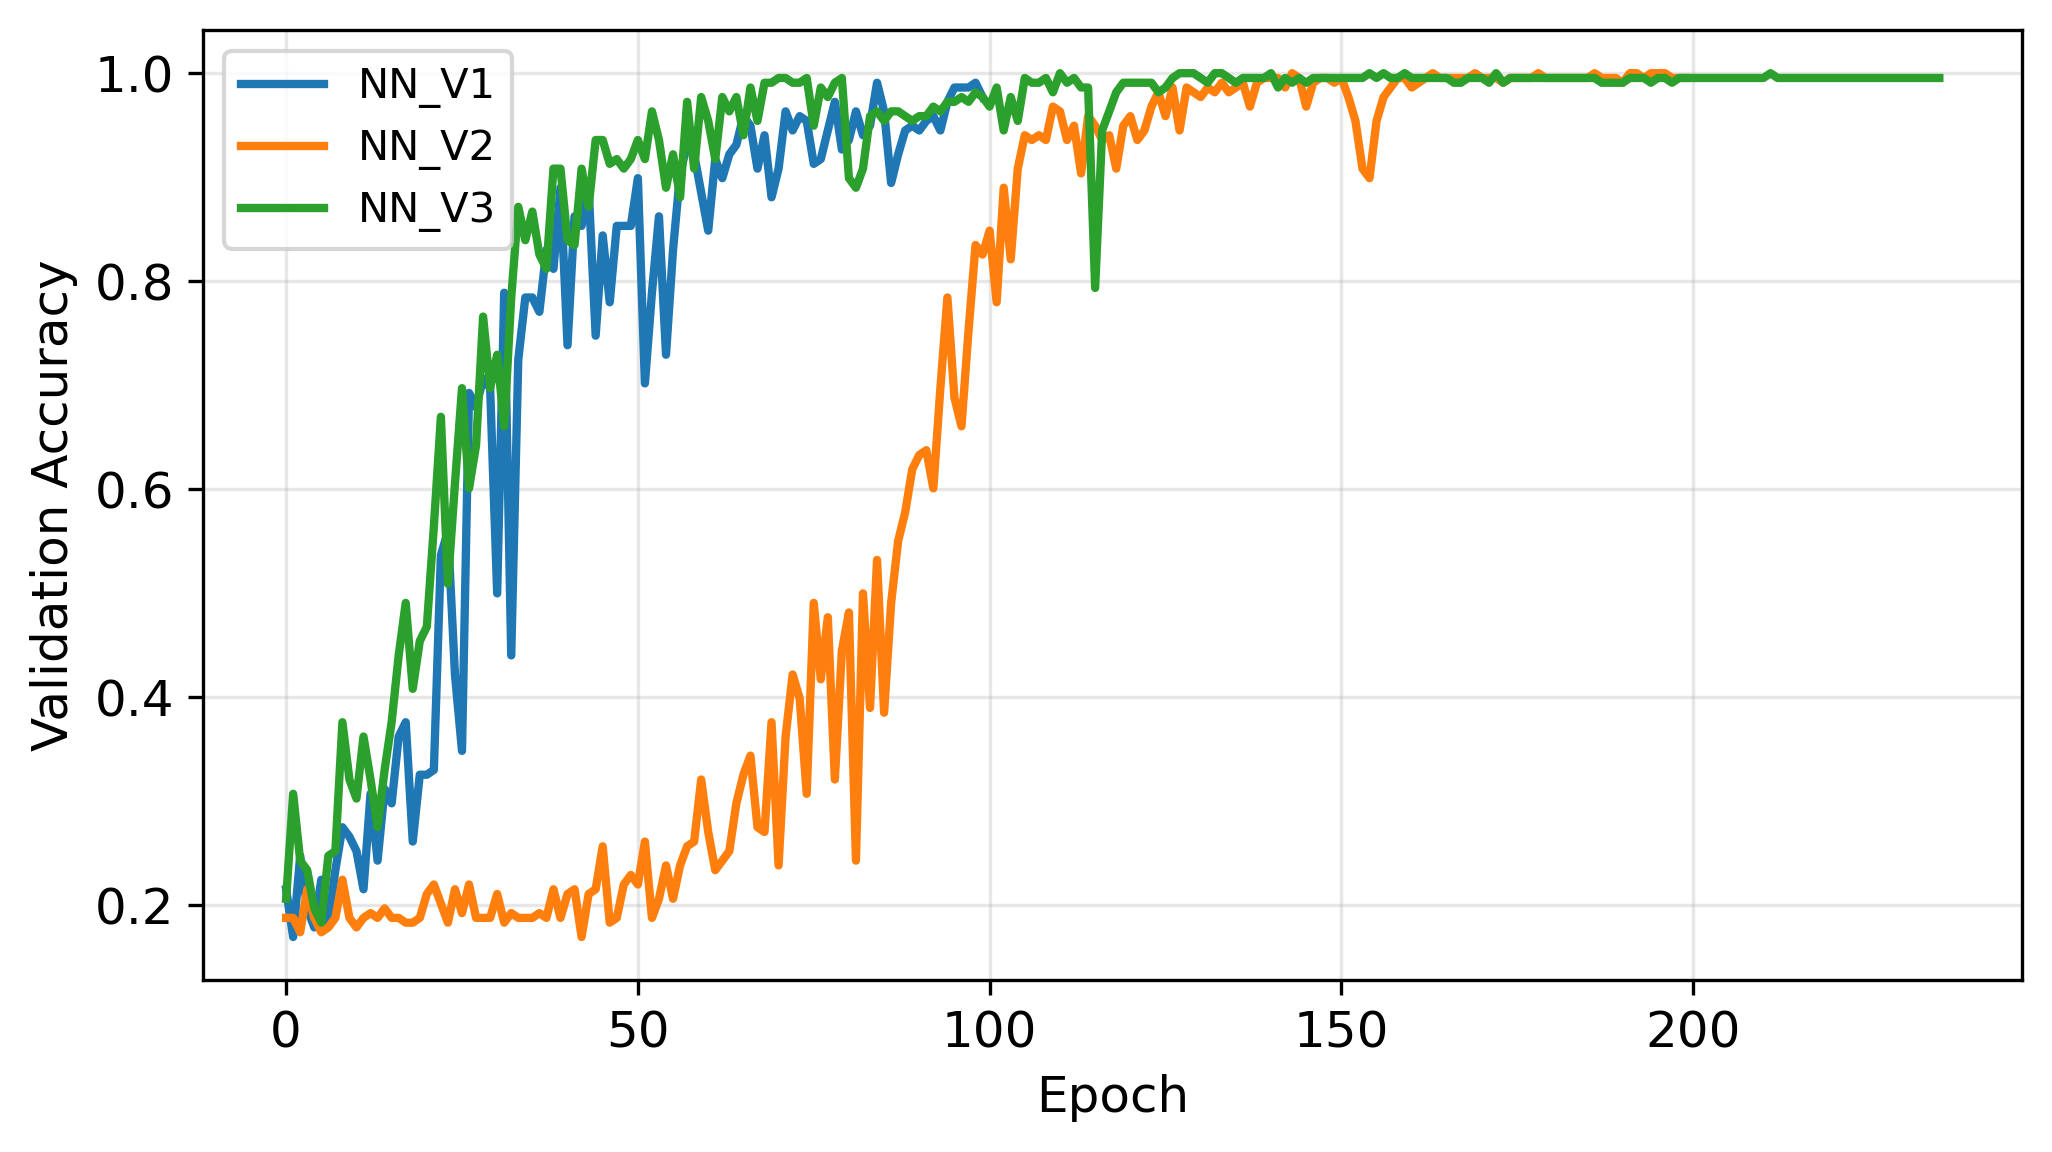

In [5]:
plt.figure(figsize=(7,4))
for m in MODELS:
    va = histories[m].get("val_accuracy", [])
    plt.plot(va, label=m, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
out = FIGS / "val_accuracy_all.png"
plt.savefig(out, bbox_inches="tight")
print(f"[saved] {out}")
plt.show()


[saved] figs/val_loss_all.png


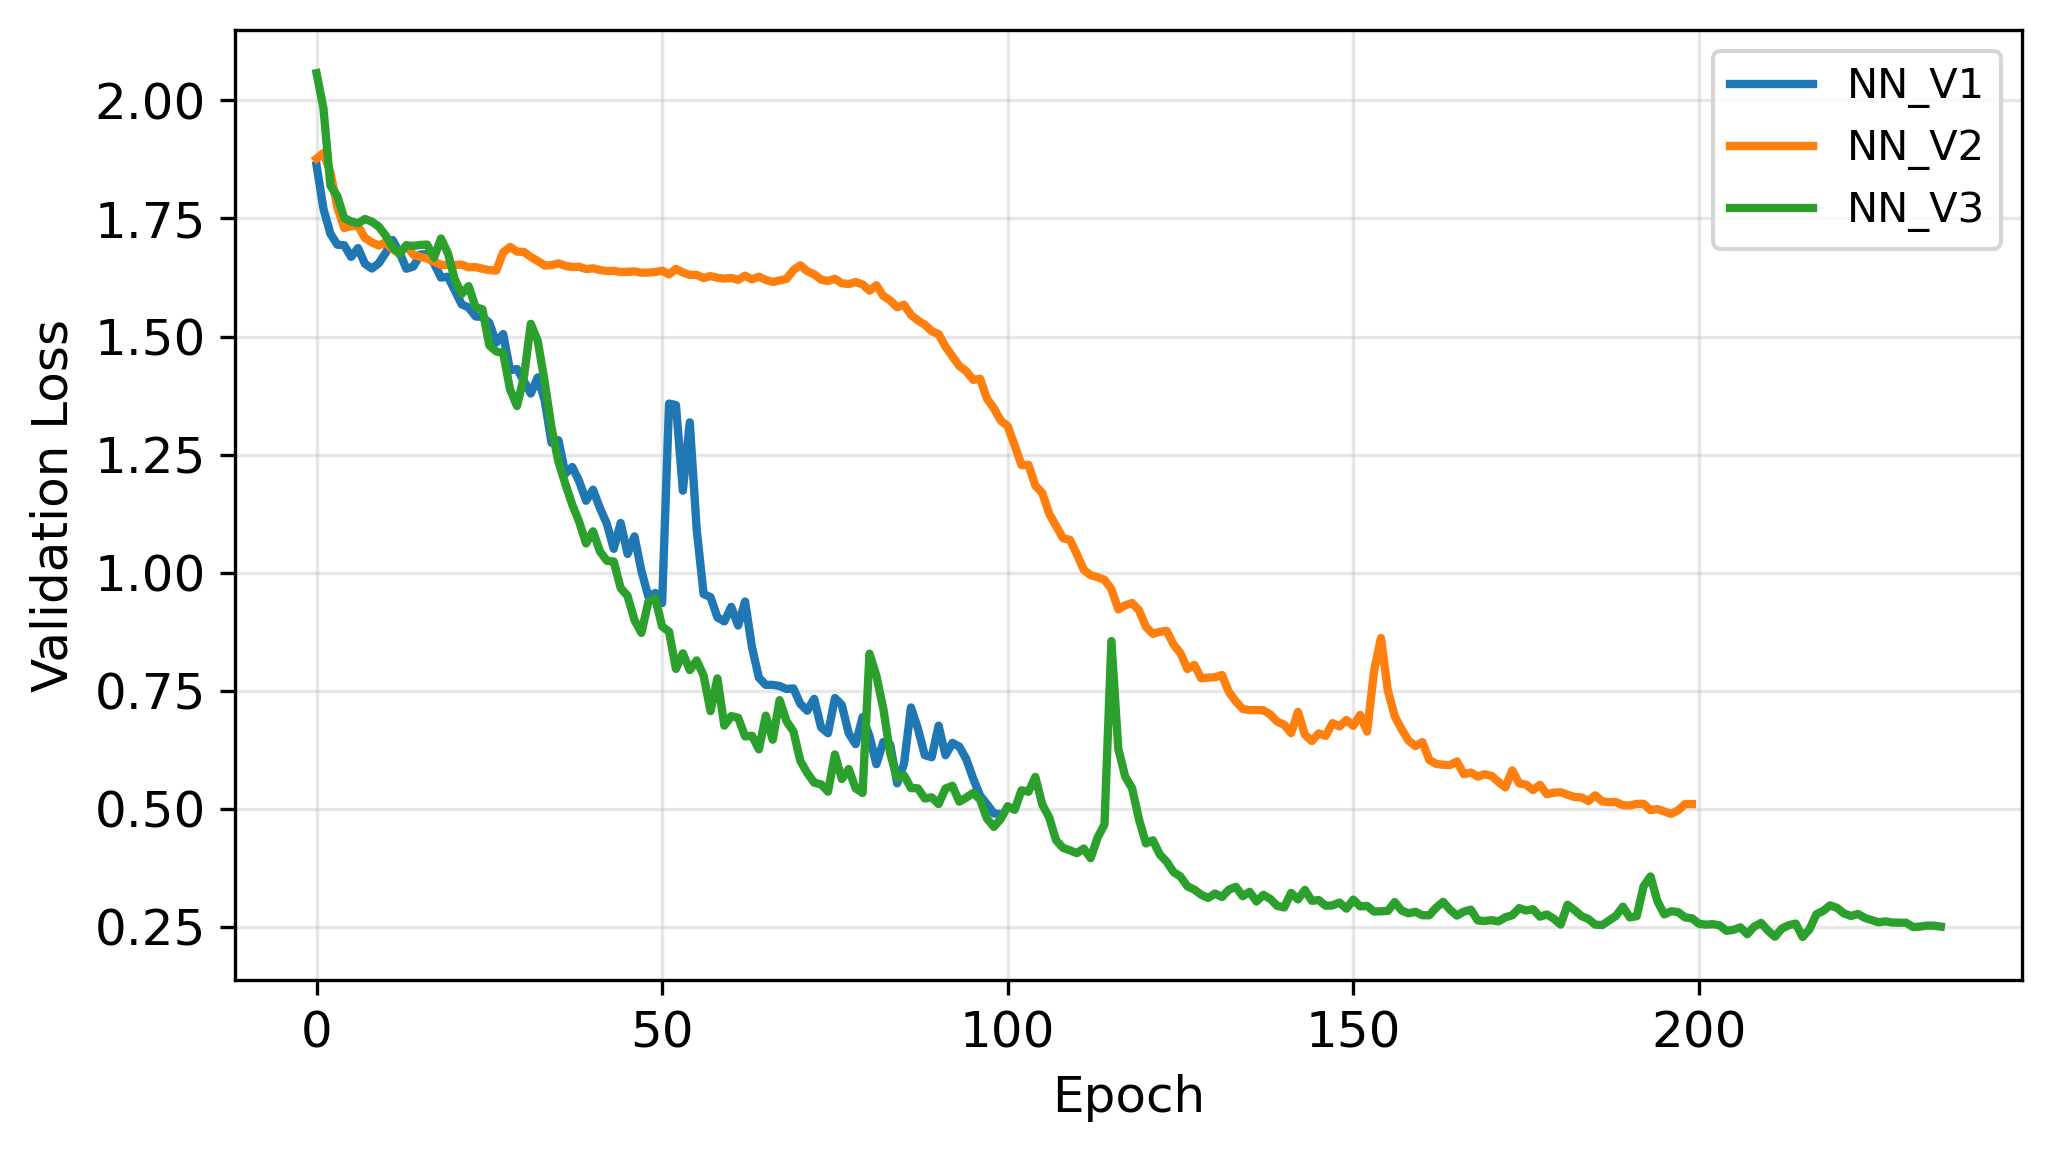

In [6]:
plt.figure(figsize=(7,4))
for m in MODELS:
    vl = histories[m].get("val_loss", [])
    plt.plot(vl, label=m, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
out = FIGS / "val_loss_all.png"
plt.savefig(out, bbox_inches="tight")
print(f"[saved] {out}")
plt.show()


In [7]:
rows = []
for m in MODELS:
    rep = reports[m]
    macro = rep.get("macro avg", {})
    best_va = float(np.max(histories[m].get("val_accuracy", []))) if len(histories[m].get("val_accuracy", [])) else None
    rows.append({
        "Model": m,
        "Precision": macro.get("precision", None),
        "Recall":    macro.get("recall", None),
        "F1-score":  macro.get("f1-score", None),
        "Support":   macro.get("support", None),
        "Best Val Acc": best_va
    })

df = pd.DataFrame(rows).set_index("Model")
display(df.style.format(precision=4))

csv_out = FIGS / "metrics_comparison.csv"
df.to_csv(csv_out)
print(f"[saved] {csv_out}")


,Precision,Recall,F1-score,Support,Best Val Acc
Model,,,,,
NN_V1,0.9842,0.9883,0.9860,218,0.9908
NN_V2,0.9762,0.9790,0.9770,218,1.0000
NN_V3,0.9947,0.9955,0.9950,218,1.0000


[saved] figs/metrics_comparison.csv


In [8]:
# Useful for SHM to understand class-wise behaviour and false negatives
blocks = []
for m in MODELS:
    rep = reports[m]
    # Keep only class-level entries
    per_class = {k: v for k, v in rep.items() if k not in ["accuracy", "macro avg", "weighted avg", "micro avg"]}
    if per_class:
        df_c = pd.DataFrame(per_class).T
        df_c["Model"] = m
        df_c = df_c.reset_index().rename(columns={"index": "Class"})
        blocks.append(df_c)

if blocks:
    per_class_df = pd.concat(blocks, axis=0, ignore_index=True)
    per_class_out = FIGS / "metrics_per_class.csv"
    per_class_df.to_csv(per_class_out, index=False)
    print(f"[saved] {per_class_out}")
else:
    print("No per-class breakdown found in classification reports.")


[saved] figs/metrics_per_class.csv


[saved] figs/confusion_matrix_NN_V1.png


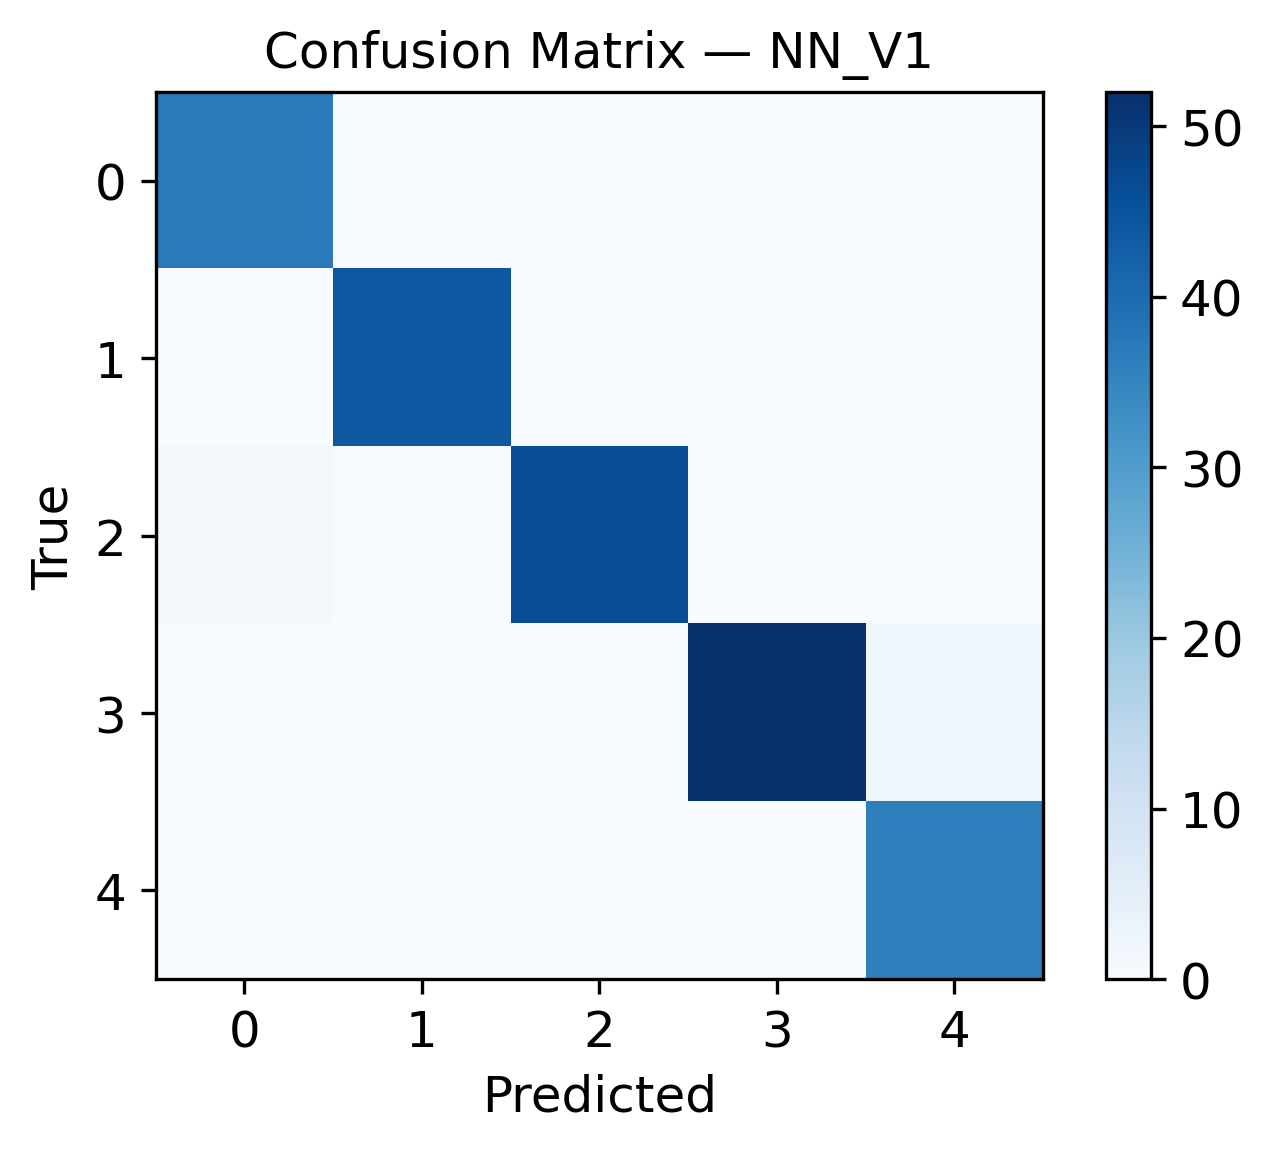

[saved] figs/confusion_matrix_NN_V2.png


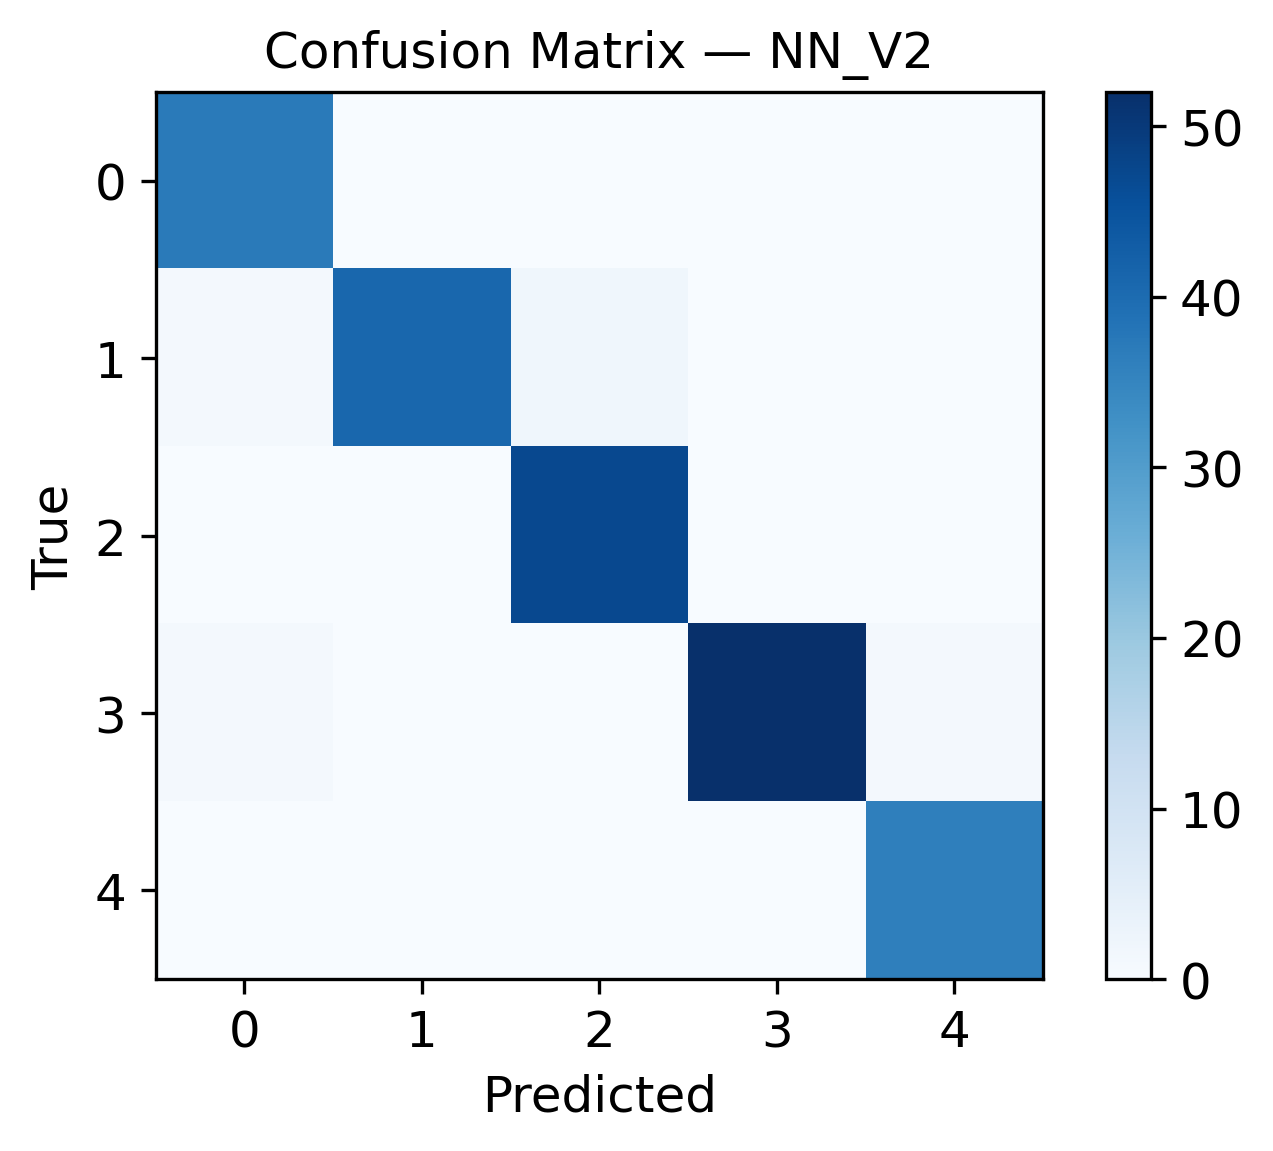

[saved] figs/confusion_matrix_NN_V3.png


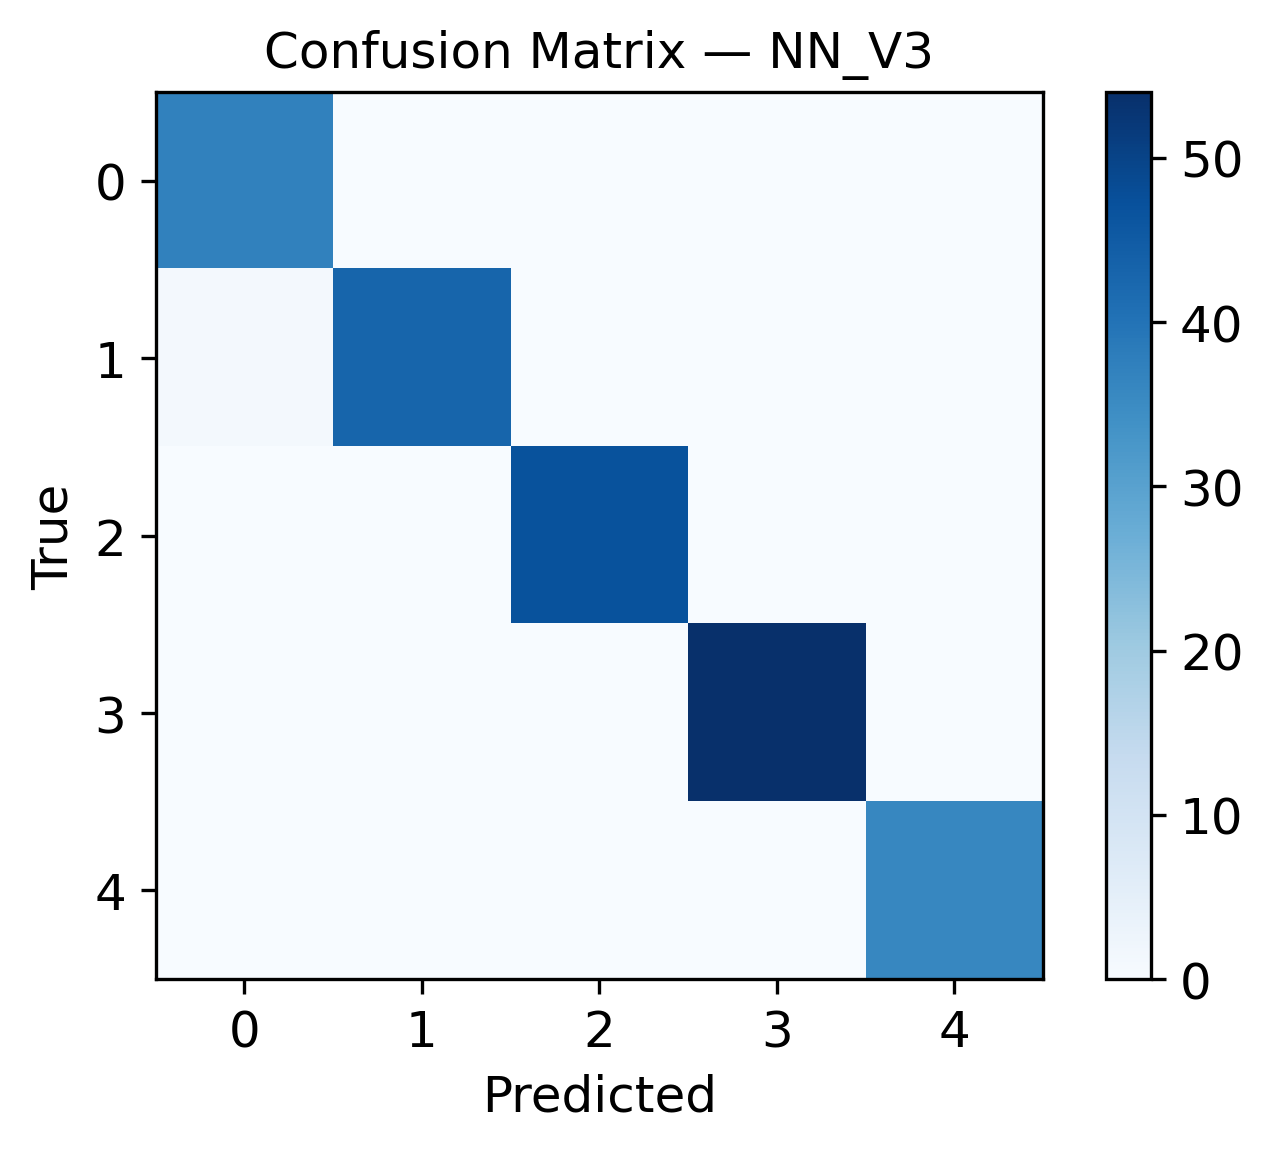

In [9]:
for m in MODELS:
    cm_path = FIGS / f"confusion_matrix_{m}.png"
    cm = cms[m]
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"Confusion Matrix — {m}")
    plt.colorbar()
    ticks = np.arange(cm.shape[0])
    plt.xticks(ticks, ticks)
    plt.yticks(ticks, ticks)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(cm_path, bbox_inches="tight")
    print(f"[saved] {cm_path}")
    plt.show()


In [10]:
from pathlib import Path
import numpy as np, pandas as pd, json

# Répertoire des exports produits par TES notebooks d’origine
MODEL_DIRS = {
    "NN_V1": Path("outputs/NN_V1"),
    "NN_V2": Path("outputs/NN_V2"),
    "NN_V3": Path("outputs/NN_V3"),
}
OUT = Path("outputs/figs_compare"); OUT.mkdir(parents=True, exist_ok=True)

def must_exist(p: Path):
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}")

def load_history_npz(d: Path):
    z = np.load(d/"history.npz", allow_pickle=False)
    return {k: z[k] for k in z.files}

problems = []
for name, d in MODEL_DIRS.items():
    try:
        must_exist(d/"history.npz")
        must_exist(d/"metrics.json")
        must_exist(d/"classification_report.json")
        must_exist(d/"confusion_matrix.csv")
        H = load_history_npz(d)
        has_val_acc = ("val_accuracy" in H) or ("val_acc" in H)
        if not has_val_acc or (len(H.get("val_accuracy", H.get("val_acc", [])))==0):
            problems.append(f"{name}: empty val_accuracy/val_acc")
        cm = pd.read_csv(d/"confusion_matrix.csv", index_col=0).to_numpy()
        if cm.shape != (5,5):
            problems.append(f"{name}: confusion_matrix is {cm.shape}, expected 5x5")
        rep = json.load(open(d/"classification_report.json"))
        if rep.get("macro avg",{}).get("recall", 0.0) == 0.0:
            problems.append(f"{name}: macro recall = 0.0 (check y_true/y_pred)")
    except Exception as e:
        problems.append(f"{name}: {e}")

print("Sanity check →", "OK ✅" if not problems else "ISSUES ⚠️")
for p in problems: print(" -", p)


Sanity check → ISSUES ⚠️
 - NN_V1: Missing: outputs/NN_V1/metrics.json
 - NN_V2: Missing: outputs/NN_V2/metrics.json
 - NN_V3: Missing: outputs/NN_V3/metrics.json


In [11]:
import matplotlib.pyplot as plt
import numpy as np, json

plt.rcParams.update({
    "font.size": 11,             # >= 10–12 pt pour lisibilité (rev B-g/h)
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# Couleurs fixes par modèle (cohérentes sur toutes les figures)
COLOR = {"NN_V1":"#1f77b4", "NN_V2":"#ff7f0e", "NN_V3":"#2ca02c"}

def load_hist_any(d):
    z = np.load(d/"history.npz")
    h = {k: z[k] for k in z.files}
    # clés robustes
    acc_tr = h.get("accuracy", h.get("sparse_categorical_accuracy", []))
    acc_va = h.get("val_accuracy", h.get("val_acc", []))
    loss_tr = h.get("loss", [])
    loss_va = h.get("val_loss", [])
    return np.array(acc_tr), np.array(acc_va), np.array(loss_tr), np.array(loss_va)

# Taille figures: 7.1 x 3.6 in ~ pleine largeur 2 colonnes
figsize = (7.1, 3.6)
dpi = 300

# --- Accuracy (train & val) ---
plt.figure(figsize=figsize, dpi=dpi)
for name, d in MODEL_DIRS.items():
    acc_tr, acc_va, _, _ = load_hist_any(d)
    if acc_tr.size:
        plt.plot(acc_tr, linestyle="--", linewidth=1.8, color=COLOR[name],
                 alpha=0.7, label=f"{name} – train")
    if acc_va.size:
        plt.plot(acc_va, linestyle="-", linewidth=2.2, marker="o", markersize=3.5,
                 color=COLOR[name], label=f"{name} – val")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (NN_V1 / V2 / V3)")
plt.grid(True, alpha=.25); plt.legend(ncol=2)
plt.tight_layout(); plt.savefig(OUT/"accuracy_train_val.png"); plt.close()

# --- Loss (train & val) ---
plt.figure(figsize=figsize, dpi=dpi)
for name, d in MODEL_DIRS.items():
    _, _, loss_tr, loss_va = load_hist_any(d)
    if loss_tr.size:
        plt.plot(loss_tr, linestyle="--", linewidth=1.8, color=COLOR[name],
                 alpha=0.7, label=f"{name} – train")
    if loss_va.size:
        plt.plot(loss_va, linestyle="-", linewidth=2.2, marker="o", markersize=3.5,
                 color=COLOR[name], label=f"{name} – val")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training vs Validation Loss (NN_V1 / V2 / V3)")
plt.grid(True, alpha=.25); plt.legend(ncol=2)
plt.tight_layout(); plt.savefig(OUT/"loss_train_val.png"); plt.close()

print("Saved:", OUT/"accuracy_train_val.png")
print("Saved:", OUT/"loss_train_val.png")


Saved: outputs/figs_compare/accuracy_train_val.png
Saved: outputs/figs_compare/loss_train_val.png


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fig, axs = plt.subplots(1, 3, figsize=(7.1, 3.0), dpi=300, constrained_layout=True)
for ax, (name, d) in zip(axs, MODEL_DIRS.items()):
    df = pd.read_csv(d/"confusion_matrix.csv", index_col=0)
    labs = df.index.tolist()
    cm = df.to_numpy()
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs)
    ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs)
    # valeurs dans les cases
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i,j]), ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axs, shrink=0.8)
plt.savefig(OUT/"confusion_matrices_grid.png"); plt.close()
print("Saved:", OUT/"confusion_matrices_grid.png")


Saved: outputs/figs_compare/confusion_matrices_grid.png


In [13]:
# ============================== #
# Reviewer Pack — V1 / V2 / V3   #
# One-cell generator             #
# ============================== #
import os, json, glob, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

warnings.filterwarnings("ignore")

# -------- 1) CONFIG --------
# Indique ici où se trouvent les sorties de chaque modèle (le code scanne récursivement ces dossiers)
ROOTS = {
    "NN_V1": "outputs/NN_V1",   # ex: "runs/NN_V1_2025-08-28" ou "." si les fichiers sont au même niveau
    "NN_V2": "outputs/NN_V2",
    "NN_V3": "outputs/NN_V3",
}
OUTDIR = Path("reviewer_pack"); OUTDIR.mkdir(parents=True, exist_ok=True)

# Couleurs fixes par modèle (compatibles daltonisme) + styles train/val
COLORS = {"NN_V1": "#1f77b4", "NN_V2": "#ff7f0e", "NN_V3": "#2ca02c"}  # bleu, orange, vert
LS_TRAIN = (0, (5, 4))   # pointillé
LS_VAL   = "solid"
MS_VAL   = 3.5           # marker size pour val

# -------- 2) UTILITAIRES --------
def _find_one(root, patterns):
    """Retourne le premier fichier correspondant aux patterns (recherche récursive)."""
    if isinstance(patterns, str): patterns = [patterns]
    for pat in patterns:
        cand = glob.glob(os.path.join(root, "**", pat), recursive=True)
        if cand: 
            # tri par longueur puis par mtime décroissant
            cand.sort(key=lambda p: (-os.path.getmtime(p), len(p)))
            return cand[0]
    return None

def load_history(root):
    """history.npz => dict avec keys: acc, val_acc, loss, val_loss (liste numpy) — gère variations de noms."""
    f = _find_one(root, ["history.npz", "hist*.npz"])
    if not f: return {}
    h = dict(np.load(f, allow_pickle=True))
    # Harmoniser clés
    keys_map = {
        "accuracy":"acc", "train_accuracy":"acc", "acc":"acc",
        "val_accuracy":"val_acc", "val_acc":"val_acc",
        "loss":"loss", "train_loss":"loss",
        "val_loss":"val_loss"
    }
    hist = {}
    for k, v in h.items():
        k2 = keys_map.get(k, None)
        if k2 is not None: hist[k2] = np.asarray(v).ravel().tolist()
    return hist

def load_labels(root):
    """Retourne la liste d'étiquettes textuelles si disponible, sinon None."""
    f = _find_one(root, ["label_encoder_classes.npy", "labels.npy", "classes.npy"])
    if not f: return None
    arr = np.load(f, allow_pickle=True)
    return [str(x) for x in arr.tolist()]

def load_predictions(root):
    """
    predictions.npz attendu avec y_true, y_pred (optionnel), y_prob (optionnel).
    Retourne y_true(np), y_pred(np), y_prob(np ou None).
    """
    f = _find_one(root, ["predictions.npz", "preds*.npz"])
    if not f: return None, None, None
    d = dict(np.load(f, allow_pickle=True))
    y_true = d.get("y_true", None)
    y_pred = d.get("y_pred", None)
    y_prob = d.get("y_prob", None)
    if y_true is not None: y_true = np.asarray(y_true).ravel()
    if y_pred is not None: y_pred = np.asarray(y_pred).ravel()
    if y_prob is not None: y_prob = np.asarray(y_prob)
    # Si proba dispo mais pas y_pred -> argmax
    if y_pred is None and y_prob is not None:
        y_pred = y_prob.argmax(axis=1)
    return y_true, y_pred, y_prob

def load_report(root):
    """classification_report.json ou metrics.json -> dict sklearn (output_dict=True)."""
    f = _find_one(root, ["classification_report.json", "metrics.json"])
    if not f: return None
    with open(f, "r", encoding="utf-8") as fh:
        try:
            obj = json.load(fh)
        except Exception:
            return None
    return obj

def load_confusion(root):
    """confusion_matrix.csv -> ndarray, sinon essayé de reconstituer via y_true/y_pred."""
    f = _find_one(root, ["confusion_matrix.csv", "confmat.csv"])
    if not f: return None
    cm = pd.read_csv(f, header=None).values
    return cm

def ensure_cm(y_true, y_pred, n_classes=None):
    if y_true is None or y_pred is None: return None
    if n_classes is None:
        n_classes = int(max(y_true.max(), y_pred.max())) + 1
    labels = np.arange(n_classes)
    return confusion_matrix(y_true, y_pred, labels=labels)

def roc_auc_macro(y_true, y_prob, n_classes):
    """Macro AUC OvR si proba dispo; sinon None."""
    if y_prob is None or y_true is None: return None
    # one-hot
    Y = np.eye(n_classes)[y_true.astype(int)]
    try:
        return float(roc_auc_score(Y, y_prob, average="macro", multi_class="ovr"))
    except Exception:
        return None

def per_class_from_report(report_dict, classes_txt):
    rows = []
    for i, c in enumerate(classes_txt):
        k = c if c in report_dict else str(i)
        if k in report_dict:
            r = report_dict[k]
            rows.append({
                "class": c, "precision": r.get("precision", np.nan),
                "recall": r.get("recall", np.nan),
                "f1": r.get("f1-score", r.get("f1", np.nan)),
                "support": r.get("support", np.nan)
            })
    return pd.DataFrame(rows)

# -------- 3) AGREGER DONNEES --------
all_hist = {}           # {model: {"acc":[...], "val_acc":[...], "loss":[...], "val_loss":[...]}}
all_cm   = {}           # {model: cm}
overall  = []           # lignes globales
per_cls  = []           # lignes par classe pour concat

# labels textuels communs si dispos
labels_txt_global = None

for model, root in ROOTS.items():
    root = str(root)
    hist = load_history(root); all_hist[model] = hist

    y_true, y_pred, y_prob = load_predictions(root)
    rep = load_report(root)

    # classes textuelles = priorité aux labels.npy ; sinon depuis report
    labels_txt = load_labels(root)
    if labels_txt is None and rep is not None:
        # tenter d'inférer à partir des clés numériques '0','1',...
        keys_num = [k for k in rep.keys() if k.isdigit()]
        if keys_num:
            labels_txt = [str(k) for k in sorted(map(int, keys_num))]
    if labels_txt is None and y_true is not None:
        labels_txt = [str(k) for k in sorted(np.unique(y_true).tolist())]
    labels_txt_global = labels_txt_global or labels_txt
    nC = len(labels_txt) if labels_txt is not None else (int(max(y_true.max(), y_pred.max()))+1 if y_true is not None and y_pred is not None else None)

    # confusion matrix
    cm = load_confusion(root)
    if cm is None:
        cm = ensure_cm(y_true, y_pred, n_classes=nC)
    if cm is not None: all_cm[model] = cm

    # métriques globales
    if rep is not None:
        acc = rep.get("accuracy", np.nan)
        mac = rep.get("macro avg", {})
        prec_m = mac.get("precision", np.nan)
        rec_m  = mac.get("recall", np.nan)
        f1_m   = mac.get("f1-score", mac.get("f1", np.nan))
    else:
        # fallback simple si pas de report
        from sklearn.metrics import accuracy_score, precision_recall_fscore_support
        acc = float((y_true == y_pred).mean()) if (y_true is not None and y_pred is not None) else np.nan
        pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0) if (y_true is not None and y_pred is not None) else (np.nan, np.nan, np.nan, None)
        prec_m, rec_m, f1_m = float(pr), float(rc), float(f1)

    auc_m = roc_auc_macro(y_true, y_prob, nC) if nC is not None else None

    overall.append({
        "model": model,
        "accuracy": round(float(acc), 4) if acc==acc else np.nan,
        "macro_precision": round(float(prec_m), 4) if prec_m==prec_m else np.nan,
        "macro_recall": round(float(rec_m), 4) if rec_m==rec_m else np.nan,
        "macro_f1": round(float(f1_m), 4) if f1_m==f1_m else np.nan,
        "macro_auc": round(float(auc_m), 4) if auc_m is not None else np.nan
    })

    # métriques par classe
    if rep is not None and labels_txt is not None:
        df_pc = per_class_from_report(rep, labels_txt)
        df_pc.insert(0, "model", model)
        per_cls.append(df_pc)
    elif (y_true is not None and y_pred is not None and labels_txt is not None):
        from sklearn.metrics import precision_recall_fscore_support
        pr, rc, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=np.arange(len(labels_txt)), zero_division=0)
        df_pc = pd.DataFrame({
            "model": model, "class": labels_txt,
            "precision": pr, "recall": rc, "f1": f1, "support": sup
        })
        per_cls.append(df_pc)

# DataFrames & exports
df_overall = pd.DataFrame(overall).sort_values("model")
df_overall.to_csv(OUTDIR / "metrics_comparison.csv", index=False)

df_percls = pd.concat(per_cls, ignore_index=True) if per_cls else pd.DataFrame()
if not df_percls.empty:
    df_percls.to_csv(OUTDIR / "metrics_per_class.csv", index=False)

# Faux négatifs par classe
fn_rows = []
for model, cm in all_cm.items():
    cm = np.asarray(cm)
    if labels_txt_global is None:
        labels_txt_global = [str(i) for i in range(cm.shape[0])]
    # FN = somme de la ligne (vérités) - diag
    FN = cm.sum(axis=1) - np.diag(cm)
    for i, label in enumerate(labels_txt_global[:cm.shape[0]]):
        fn_rows.append({"model": model, "class": label, "FN": int(FN[i])})
df_fn = pd.DataFrame(fn_rows)
if not df_fn.empty:
    df_fn.to_csv(OUTDIR / "false_negatives.csv", index=False)
    # Top confusions (paires off-diagonal)
    top_pairs = {}
    for model, cm in all_cm.items():
        cm = np.asarray(cm)
        off = cm.copy()
        np.fill_diagonal(off, 0)
        # top-5 paires confondues
        pairs = []
        for i in range(off.shape[0]):
            for j in range(off.shape[1]):
                if i!=j and off[i,j]>0:
                    pairs.append((labels_txt_global[i], labels_txt_global[j], int(off[i,j])))
        pairs.sort(key=lambda t: t[2], reverse=True)
        top_pairs[model] = pairs[:5]
    with open(OUTDIR / "top_confusions.json", "w") as fh:
        json.dump(top_pairs, fh, indent=2)

# -------- 4) FIGURES : train/val accuracy & loss --------
plt.rcParams.update({
    "figure.dpi": 200, "savefig.dpi": 300,
    "font.size": 12, "axes.titlesize": 18, "axes.labelsize": 16,
    "legend.fontsize": 14, "xtick.labelsize": 12, "ytick.labelsize": 12
})

def _plot_tv(ax, hist, color, label_train, label_val):
    acc = hist.get("acc"); vacc = hist.get("val_acc")
    if acc:
        ax.plot(acc, ls=LS_TRAIN, color=color, label=label_train, linewidth=2.0)
    if vacc:
        ax.plot(vacc, ls=LS_VAL, marker="o", markersize=MS_VAL, color=color, label=label_val, linewidth=2.2, alpha=0.95)

# Accuracy
fig, ax = plt.subplots(figsize=(10.5, 6.2))
for m, h in all_hist.items():
    _plot_tv(ax, h, COLORS[m], f"{m} – train", f"{m} – val")
ax.set_title("Training vs Validation Accuracy (NN_V1 / V2 / V3)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.grid(True, alpha=0.25); ax.legend(ncols=2, frameon=True)
fig.tight_layout()
fig.savefig(OUTDIR / "train_val_accuracy.png", bbox_inches="tight")
plt.close(fig)

# Loss
fig, ax = plt.subplots(figsize=(10.5, 6.2))
for m, h in all_hist.items():
    loss = h.get("loss"); vloss = h.get("val_loss")
    if loss:
        ax.plot(loss, ls=LS_TRAIN, color=COLORS[m], label=f"{m} – train", linewidth=2.0)
    if vloss:
        ax.plot(vloss, ls=LS_VAL, marker="o", markersize=MS_VAL, color=COLORS[m], label=f"{m} – val", linewidth=2.2, alpha=0.95)
ax.set_title("Training vs Validation Loss (NN_V1 / V2 / V3)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.grid(True, alpha=0.25); ax.legend(ncols=2, frameon=True)
fig.tight_layout()
fig.savefig(OUTDIR / "train_val_loss.png", bbox_inches="tight")
plt.close(fig)

# -------- 5) FIGURE : Grille de matrices de confusion --------
if all_cm:
    ms = sorted(all_cm.keys())
    n = len(ms)
    fig, axes = plt.subplots(1, n, figsize=(4.6*n, 4.2), constrained_layout=True)
    if n == 1: axes = [axes]
    vmax = max(cm.max() for cm in all_cm.values())
    for ax, m in zip(axes, ms):
        cm = all_cm[m]
        im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=vmax)
        ax.set_title(m, pad=8)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        # ticks
        if labels_txt_global:
            ax.set_xticks(range(len(labels_txt_global))); ax.set_yticks(range(len(labels_txt_global)))
            ax.set_xticklabels(labels_txt_global, rotation=0); ax.set_yticklabels(labels_txt_global)
        # valeurs
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, str(int(cm[i, j])), ha="center", va="center", fontsize=9)
    # barre de couleur à droite
    cax = fig.colorbar(im, ax=axes, fraction=0.04, pad=0.02)
    cax.set_label("Count")
    fig.suptitle("Confusion Matrices — Test Set", fontsize=18, y=1.05)
    fig.savefig(OUTDIR / "confusion_matrices_grid.png", bbox_inches="tight")
    plt.close(fig)

# -------- 6) Sauvegarde des tables lisibles Word (arrondies) --------
df_overall_rounded = df_overall.copy()
for col in ["accuracy","macro_precision","macro_recall","macro_f1","macro_auc"]:
    if col in df_overall_rounded:
        df_overall_rounded[col] = df_overall_rounded[col].map(lambda x: f"{x:.4f}" if pd.notnull(x) else "")
df_overall_rounded.to_csv(OUTDIR / "metrics_comparison_rounded.csv", index=False)

if not df_percls.empty:
    df_percls_round = df_percls.copy()
    for col in ["precision","recall","f1"]:
        if col in df_percls_round:
            df_percls_round[col] = df_percls_round[col].map(lambda x: f"{x:.4f}")
    df_percls_round.to_csv(OUTDIR / "metrics_per_class_rounded.csv", index=False)

print("✅ Reviewer pack généré dans:", OUTDIR.resolve())
print(" - metrics_comparison.csv / metrics_comparison_rounded.csv")
print(" - metrics_per_class.csv / metrics_per_class_rounded.csv (si dispo)")
print(" - false_negatives.csv, top_confusions.json (si CM dispo)")
print(" - train_val_accuracy.png, train_val_loss.png, confusion_matrices_grid.png")


✅ Reviewer pack généré dans: /home/a.riyahi/spinn_project/reviewer_pack
 - metrics_comparison.csv / metrics_comparison_rounded.csv
 - metrics_per_class.csv / metrics_per_class_rounded.csv (si dispo)
 - false_negatives.csv, top_confusions.json (si CM dispo)
 - train_val_accuracy.png, train_val_loss.png, confusion_matrices_grid.png


In [14]:
# ==== Cell 1: helpers & style (run once) ====
import os, json, numpy as np
import matplotlib.pyplot as plt

# ---------- Style global (Word-ready) ----------
plt.rcParams.update({
    "figure.figsize": (12, 6.8),
    "figure.dpi": 110,               # affichage
    "savefig.dpi": 400,              # export haute résolution
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "legend.fontsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "lines.linewidth": 2.5,
    "text.usetex": False,
})

# ---------- Mapping couleurs par modèle ----------
MODEL_COLORS = {
    "NN_V1": "#1f77b4",  # bleu
    "NN_V2": "#ff7f0e",  # orange
    "NN_V3": "#2ca02c",  # vert
}

# ---------- Où trouver les historiques ----------
# 1) Si vous avez déjà un dict "histories" en mémoire: {"NN_V1": history_dict, ...} il sera utilisé automatiquement.
# 2) Sinon, précisez ici des chemins vers history.npz/json par modèle:
HISTORY_FILES = {
    "NN_V1": "outputs/NN_V1/history.npz",   # <-- ajuster si besoin
    "NN_V2": "outputs/NN_V2/history.npz",
    "NN_V3": "outputs/NN_V3/history.npz",
}
# Fallbacks testés automatiquement: history.json, history.npz dans ./NN_Vx/ ou ./outputs/NN_Vx/

def _standardize_history(h):
    """Accepte dict Keras, .npz ou .json -> dict python avec clés standardisées."""
    if isinstance(h, dict) and "history" in h:
        h = h["history"]
    # Keras peut nommer acc/val_acc ou accuracy/val_accuracy
    def get_key(d, *candidates):
        for k in candidates:
            if k in d: return k
        return None
    acc_k = get_key(h, "accuracy", "acc")
    val_acc_k = get_key(h, "val_accuracy", "val_acc")
    loss_k = get_key(h, "loss")
    val_loss_k = get_key(h, "val_loss")
    if not all([acc_k, val_acc_k, loss_k, val_loss_k]):
        raise RuntimeError("History keys not found. Expected accuracy/val_accuracy/loss/val_loss.")
    return {
        "accuracy": np.asarray(h[acc_k]),
        "val_accuracy": np.asarray(h[val_acc_k]),
        "loss": np.asarray(h[loss_k]),
        "val_loss": np.asarray(h[val_loss_k]),
    }

def _load_npz(path):
    data = np.load(path, allow_pickle=True)
    # (i) direct arrays
    if set(["accuracy","val_accuracy","loss","val_loss"]).issubset(data.files):
        return {k: data[k] for k in ["accuracy","val_accuracy","loss","val_loss"]}
    # (ii) history enregistré comme dict picklé
    if "history" in data.files:
        return _standardize_history(data["history"].item())
    raise RuntimeError(f"NPZ does not contain expected keys: {list(data.files)}")

def load_history_for(model_key):
    """Charge l'historique pour NN_V1/2/3 depuis 'histories' (si présent) sinon depuis fichiers."""
    # 1) mémoire
    if "histories" in globals() and model_key in histories:
        return _standardize_history(histories[model_key])
    # 2) chemin explicite
    candidates = []
    if model_key in HISTORY_FILES and HISTORY_FILES[model_key]:
        candidates += [HISTORY_FILES[model_key]]
    # 3) fallbacks usuels
    candidates += [
        os.path.join("outputs", model_key, "history.npz"),
        os.path.join("outputs", model_key, "history.json"),
        os.path.join(model_key, "history.npz"),
        os.path.join(model_key, "history.json"),
        "history.npz", "history.json"
    ]
    for p in candidates:
        if os.path.isfile(p):
            ext = os.path.splitext(p)[1].lower()
            if ext == ".npz":
                return _standardize_history(_load_npz(p))
            elif ext == ".json":
                with open(p, "r", encoding="utf-8") as f:
                    return _standardize_history(json.load(f))
    raise FileNotFoundError(f"No history found for {model_key}. Checked: {candidates}")

def plot_acc_loss_for_model(model_key, fig_number, outdir="figs"):
    """Crée 'Figure N: Accuracy/Loss curves for MODEL' et enregistre PNG+PDF."""
    os.makedirs(outdir, exist_ok=True)
    col = MODEL_COLORS.get(model_key, "#444444")
    H = load_history_for(model_key)

    epochs = np.arange(1, len(H["accuracy"])+1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))
    fig.suptitle(f"Figure {fig_number}. Accuracy/Loss curves for {model_key.replace('_', ' ')}", y=1.02)

    # ---- Accuracy ----
    ax = axes[0]
    ax.plot(epochs, H["accuracy"], linestyle="--", color=col, alpha=0.95, label=f"{model_key} — train")
    ax.plot(epochs, H["val_accuracy"], linestyle="-", marker="o", markersize=3.0,
            color=col, alpha=0.95, label=f"{model_key} — val")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.set_ylim(0.15, 1.02)
    ax.legend(loc="lower right", frameon=True)

    # ---- Loss ----
    ax = axes[1]
    ax.plot(epochs, H["loss"], linestyle="--", color=col, alpha=0.95, label=f"{model_key} — train")
    ax.plot(epochs, H["val_loss"], linestyle="-", marker="o", markersize=3.0,
            color=col, alpha=0.95, label=f"{model_key} — val")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(loc="upper right", frameon=True)

    plt.tight_layout()

    base = f"{outdir}/Fig{fig_number}_{model_key}_AccLoss"
    plt.savefig(base + ".png", dpi=400, bbox_inches="tight")
    plt.savefig(base + ".pdf", bbox_inches="tight")
    print(f"Saved: {base}.png  and  {base}.pdf")
    plt.show()


Saved: figs/Fig3_NN_V1_AccLoss.png  and  figs/Fig3_NN_V1_AccLoss.pdf


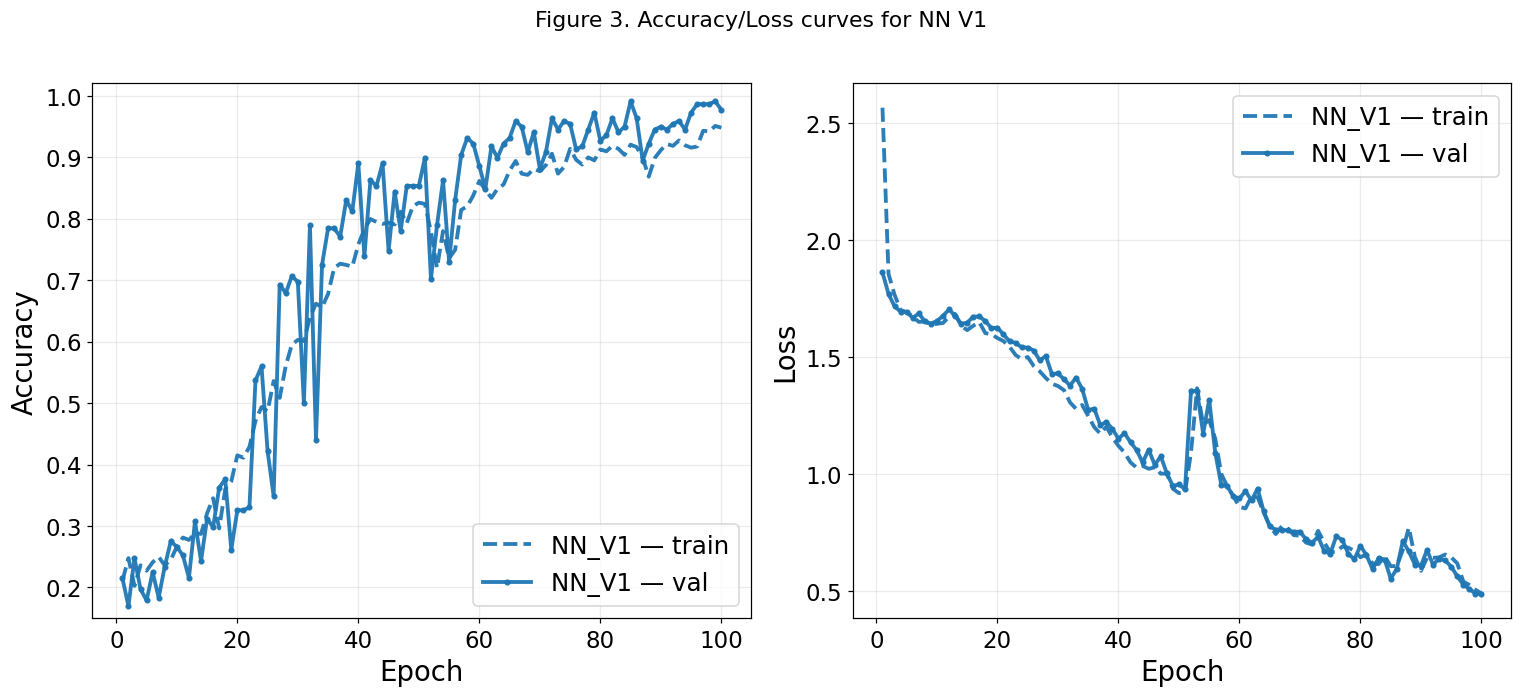

Saved: figs/Fig4_NN_V2_AccLoss.png  and  figs/Fig4_NN_V2_AccLoss.pdf


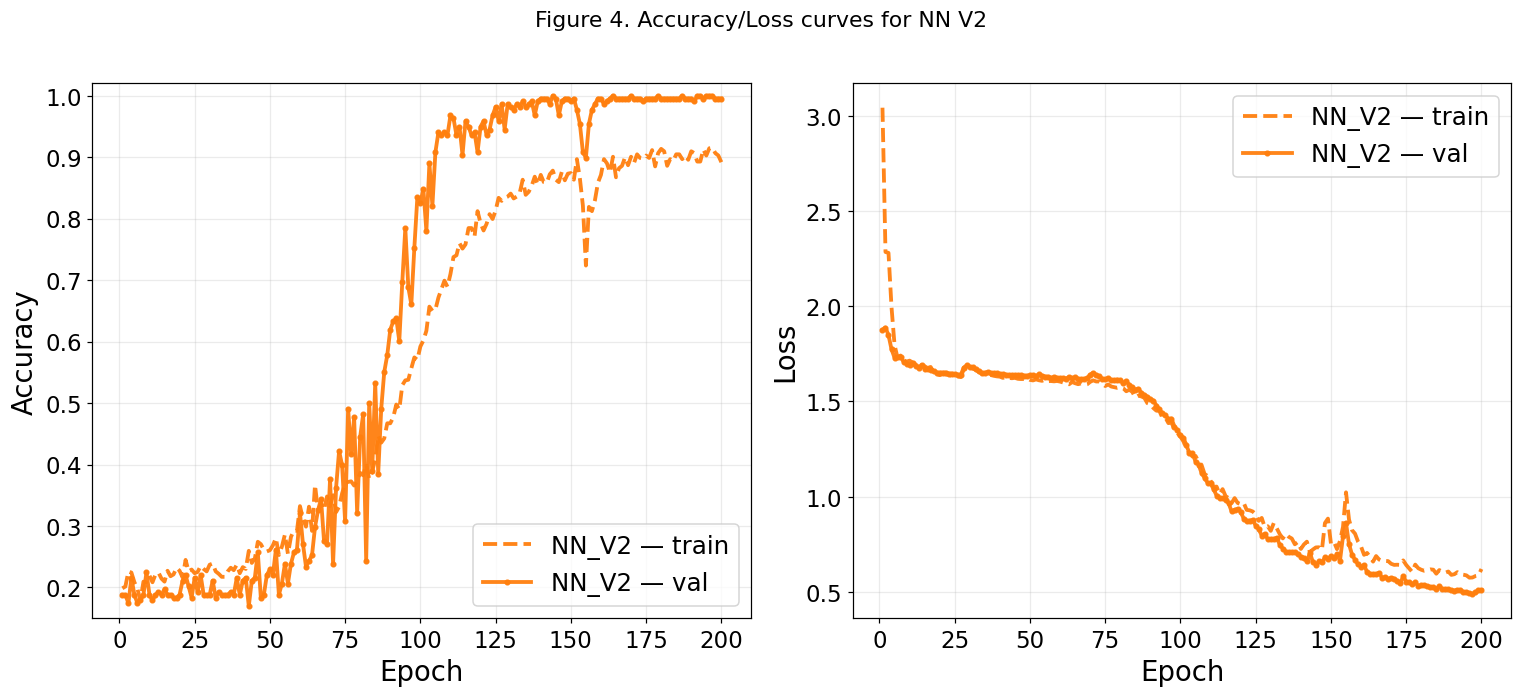

Saved: figs/Fig5_NN_V3_AccLoss.png  and  figs/Fig5_NN_V3_AccLoss.pdf


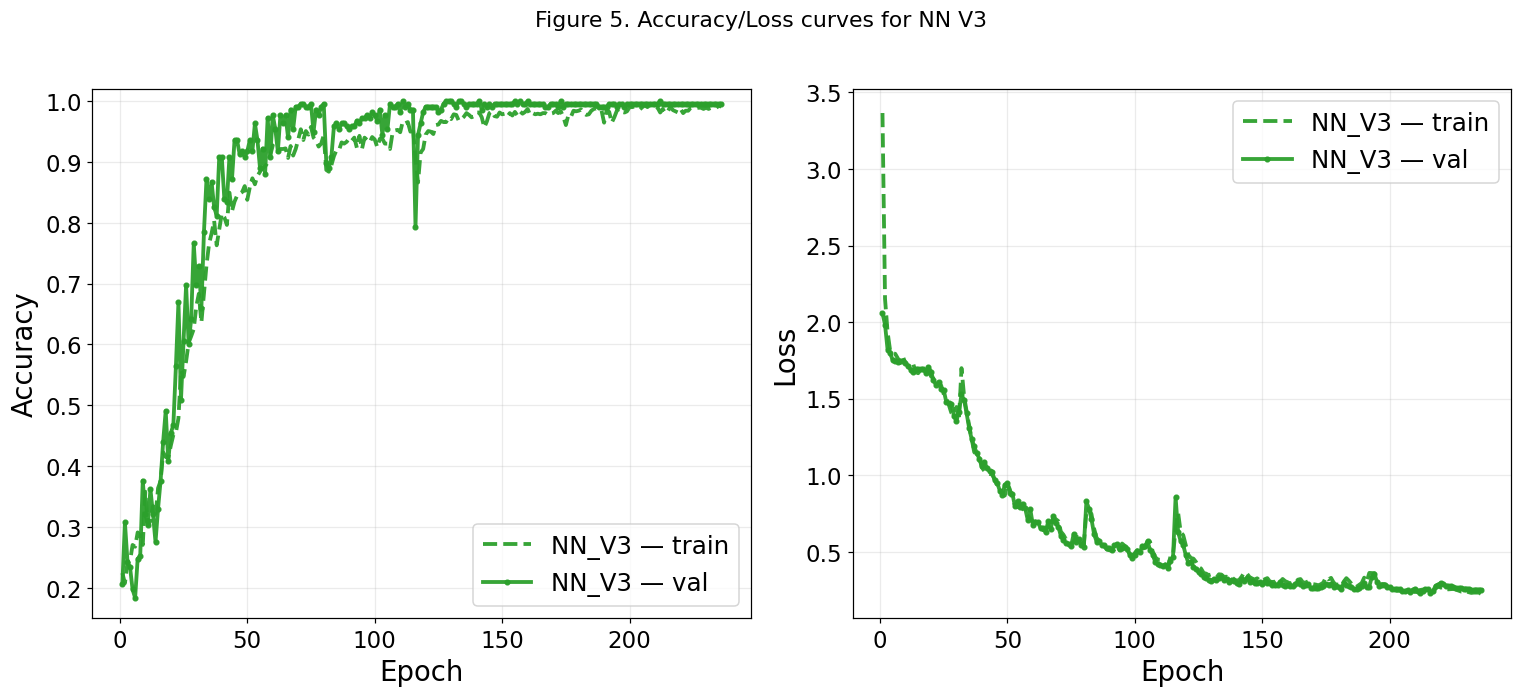

In [15]:
# ==== Cell 2: generate per-model figures ====
# Numéros/fichiers conformes à votre manuscrit
plot_acc_loss_for_model("NN_V1", fig_number=3, outdir="figs")
plot_acc_loss_for_model("NN_V2", fig_number=4, outdir="figs")
plot_acc_loss_for_model("NN_V3", fig_number=5, outdir="figs")


In [16]:
# --- Patch du traceur pour un layout vertical "journal 2 colonnes" ---
import os, numpy as np, json
import matplotlib.pyplot as plt

# tailles standard (pouces) : simple colonne ≈ 3.5", double ≈ 7.2"
SINGLE_COL_W = 3.5
DOUBLE_COL_W = 7.2

def _standardize_history(h):
    if isinstance(h, dict) and "history" in h:
        h = h["history"]
    def pick(d,*ks): 
        for k in ks:
            if k in d: return k
        return None
    ak = pick(h,"accuracy","acc")
    vak = pick(h,"val_accuracy","val_acc")
    lk = pick(h,"loss")
    vlk = pick(h,"val_loss")
    if not all([ak,vak,lk,vlk]):
        raise RuntimeError("History must contain accuracy/val_accuracy/loss/val_loss.")
    return {
        "accuracy": np.asarray(h[ak]),
        "val_accuracy": np.asarray(h[vak]),
        "loss": np.asarray(h[lk]),
        "val_loss": np.asarray(h[vlk]),
    }

def _load_npz(path):
    data = np.load(path, allow_pickle=True)
    if set(["accuracy","val_accuracy","loss","val_loss"]).issubset(data.files):
        return {k: data[k] for k in ["accuracy","val_accuracy","loss","val_loss"]}
    if "history" in data.files:
        return _standardize_history(data["history"].item())
    raise RuntimeError(f"Unexpected NPZ keys: {list(data.files)}")

def load_history_for(model_key):
    if "histories" in globals() and model_key in histories:
        return _standardize_history(histories[model_key])
    candidates = []
    if "HISTORY_FILES" in globals() and model_key in HISTORY_FILES:
        candidates += [HISTORY_FILES[model_key]]
    candidates += [
        os.path.join("outputs", model_key, "history.npz"),
        os.path.join("outputs", model_key, "history.json"),
        os.path.join(model_key, "history.npz"),
        os.path.join(model_key, "history.json"),
        "history.npz", "history.json",
    ]
    for p in candidates:
        if p and os.path.isfile(p):
            ext = os.path.splitext(p)[1].lower()
            if ext==".npz": return _standardize_history(_load_npz(p))
            if ext==".json": return _standardize_history(json.load(open(p,"r",encoding="utf-8")))
    raise FileNotFoundError(f"No history found for {model_key}. Checked: {candidates}")

def plot_acc_loss_vertical(model_key, fig_number, column="single", outdir="figs"):
    """Empile Accuracy (haut) et Loss (bas), prêt pour une colonne."""
    os.makedirs(outdir, exist_ok=True)
    H = load_history_for(model_key)
    col = MODEL_COLORS.get(model_key, "#444444") if "MODEL_COLORS" in globals() else "#1f77b4"

    width = SINGLE_COL_W if column=="single" else DOUBLE_COL_W
    height = width * 2.2   # ratio assez haut pour 2 panneaux lisibles
    # micro-ajustements de police pour petite largeur
    base = 9 if column=="single" else 11
    plt_rc = {
        "figure.figsize": (width, height),
        "axes.titlesize": base+2,
        "axes.labelsize": base,
        "legend.fontsize": base-1,
        "xtick.labelsize": base-1,
        "ytick.labelsize": base-1,
        "lines.linewidth": 2.2,
        "savefig.dpi": 600,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
    old = {k: plt.rcParams[k] for k in plt_rc}
    plt.rcParams.update(plt_rc)

    epochs = np.arange(1, len(H["accuracy"])+1)
    fig, axes = plt.subplots(2, 1, sharex=True)
    fig.suptitle(f"Figure {fig_number}. Accuracy/Loss curves for {model_key.replace('_',' ')}", y=0.99)

    # Accuracy (top)
    ax = axes[0]
    ax.plot(epochs, H["accuracy"], ls="--", color=col, label=f"{model_key} — train")
    ax.plot(epochs, H["val_accuracy"], ls="-", marker="o", markersize=2.2, color=col, label=f"{model_key} — val")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.15, 1.02)
    ax.legend(loc="lower right", frameon=True)

    # Loss (bottom)
    ax = axes[1]
    ax.plot(epochs, H["loss"], ls="--", color=col, label=f"{model_key} — train")
    ax.plot(epochs, H["val_loss"], ls="-", marker="o", markersize=2.2, color=col, label=f"{model_key} — val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(loc="upper right", frameon=True)

    fig.tight_layout(rect=(0,0,1,0.98))
    basepath = f"{outdir}/Fig{fig_number}_{model_key}_AccLoss_vertical_{column}"
    plt.savefig(basepath + ".png", bbox_inches="tight")
    plt.savefig(basepath + ".pdf", bbox_inches="tight")   # vectoriel (idéal impression)
    print("Saved:", basepath + ".png", "and", basepath + ".pdf")
    # restore rc
    plt.rcParams.update(old)
    plt.show()


Saved: figs/Fig3_NN_V1_AccLoss_vertical_single.png and figs/Fig3_NN_V1_AccLoss_vertical_single.pdf


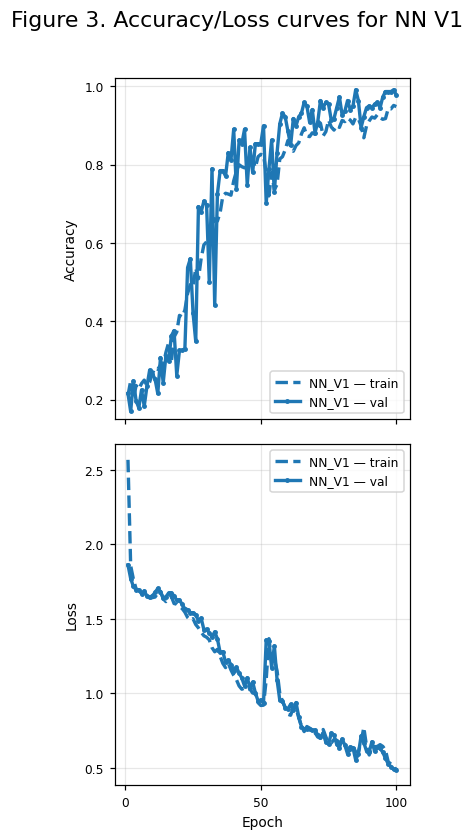

Saved: figs/Fig4_NN_V2_AccLoss_vertical_single.png and figs/Fig4_NN_V2_AccLoss_vertical_single.pdf


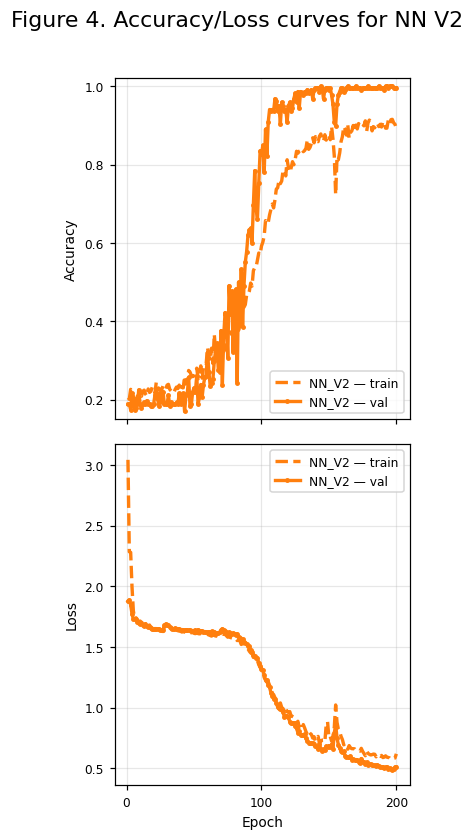

Saved: figs/Fig5_NN_V3_AccLoss_vertical_single.png and figs/Fig5_NN_V3_AccLoss_vertical_single.pdf


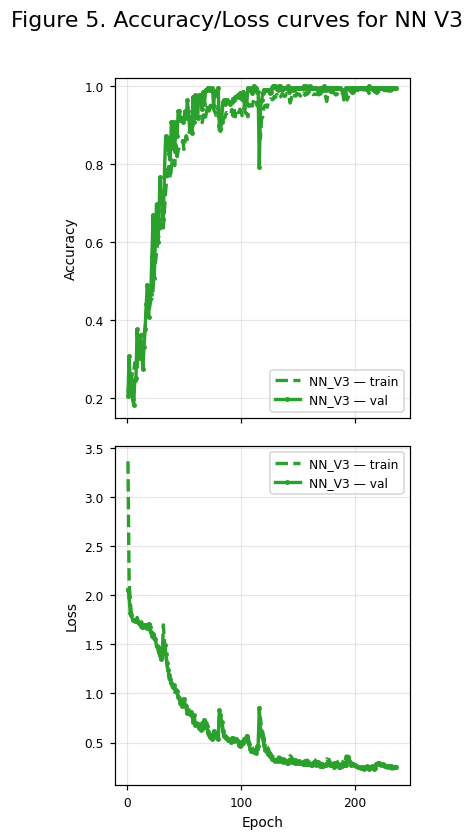

In [17]:
# === Génération verticale (simple colonne) ===
plot_acc_loss_vertical("NN_V1", fig_number=3, column="single", outdir="figs")
plot_acc_loss_vertical("NN_V2", fig_number=4, column="single", outdir="figs")
plot_acc_loss_vertical("NN_V3", fig_number=5, column="single", outdir="figs")


In [18]:
# Traceur vertical Accuracy (haut) + Loss (bas), sans numéro/titre dans l'image
import os, json, numpy as np, matplotlib.pyplot as plt

SINGLE_COL_W = 3.5   # pouces (largeur colonne)
MODEL_COLORS = {
    "NN_V1": "#1f77b4",  # bleu
    "NN_V2": "#ff7f0e",  # orange
    "NN_V3": "#2ca02c",  # vert
}

def _standardize_history(h):
    if isinstance(h, dict) and "history" in h:
        h = h["history"]
    def pick(d,*ks):
        for k in ks:
            if k in d: return k
        return None
    ak = pick(h,"accuracy","acc")
    vak = pick(h,"val_accuracy","val_acc")
    lk = pick(h,"loss")
    vlk = pick(h,"val_loss")
    if not all([ak,vak,lk,vlk]):
        raise RuntimeError("History must contain accuracy/val_accuracy/loss/val_loss.")
    return {
        "accuracy": np.asarray(h[ak]),
        "val_accuracy": np.asarray(h[vak]),
        "loss": np.asarray(h[lk]),
        "val_loss": np.asarray(h[vlk]),
    }

def _load_npz(path):
    data = np.load(path, allow_pickle=True)
    if set(["accuracy","val_accuracy","loss","val_loss"]).issubset(data.files):
        return {k: data[k] for k in ["accuracy","val_accuracy","loss","val_loss"]}
    if "history" in data.files:
        return _standardize_history(data["history"].item())
    raise RuntimeError(f"Unexpected NPZ keys: {list(data.files)}")

def load_history_for(model_key):
    # essaie d'abord un dict 'histories' déjà en mémoire
    if "histories" in globals() and model_key in histories:
        return _standardize_history(histories[model_key])
    # sinon, cherche des fichiers usuels
    candidates = []
    if "HISTORY_FILES" in globals() and model_key in HISTORY_FILES:
        candidates += [HISTORY_FILES[model_key]]
    candidates += [
        os.path.join("outputs", model_key, "history.npz"),
        os.path.join("outputs", model_key, "history.json"),
        os.path.join(model_key, "history.npz"),
        os.path.join(model_key, "history.json"),
        "history.npz", "history.json",
    ]
    for p in candidates:
        if p and os.path.isfile(p):
            ext = os.path.splitext(p)[1].lower()
            return _standardize_history(_load_npz(p) if ext==".npz" else json.load(open(p,"r",encoding="utf-8")))
    raise FileNotFoundError(f"No history found for {model_key}. Checked: {candidates}")

def plot_acc_loss_vertical_no_title(model_key, column_width=SINGLE_COL_W, outdir="figs"):
    """Empile Accuracy (haut) + Loss (bas), sans titre/numéro dans l'image."""
    os.makedirs(outdir, exist_ok=True)
    H = load_history_for(model_key)
    col = MODEL_COLORS.get(model_key, "#444444")

    width = column_width
    height = width * 2.2  # assez haut pour 2 panneaux lisibles

    base = 9  # tailles pour une colonne
    rc_new = {
        "figure.figsize": (width, height),
        "axes.titlesize": base+2,
        "axes.labelsize": base,
        "legend.fontsize": base-1,
        "xtick.labelsize": base-1,
        "ytick.labelsize": base-1,
        "lines.linewidth": 2.4,
        "savefig.dpi": 600,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
    old = {k: plt.rcParams[k] for k in rc_new}
    plt.rcParams.update(rc_new)

    epochs = np.arange(1, len(H["accuracy"])+1)
    fig, axes = plt.subplots(2, 1, sharex=True)

    # Accuracy (haut) — train pointillé, val plein + marqueurs
    ax = axes[0]
    ax.plot(epochs, H["accuracy"], ls="--", color=col, label=f"{model_key} — train")
    ax.plot(epochs, H["val_accuracy"], ls="-", marker="o", markersize=2.2,
            color=col, label=f"{model_key} — val")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.0, 1.02)
    ax.legend(loc="lower right", frameon=True)

    # Loss (bas)
    ax = axes[1]
    ax.plot(epochs, H["loss"], ls="--", color=col, label=f"{model_key} — train")
    ax.plot(epochs, H["val_loss"], ls="-", marker="o", markersize=2.2,
            color=col, label=f"{model_key} — val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(loc="upper right", frameon=True)

    fig.tight_layout()
    stem = f"{outdir}/{model_key}_AccLoss_vertical_single"
    plt.savefig(stem + ".png", bbox_inches="tight")
    plt.savefig(stem + ".pdf", bbox_inches="tight")  # vectoriel pour Word/impression
    print("Saved:", stem + ".png", "and", stem + ".pdf")

    plt.rcParams.update(old)
    plt.show()



Saved: figs/NN_V1_AccLoss_vertical_single.png and figs/NN_V1_AccLoss_vertical_single.pdf


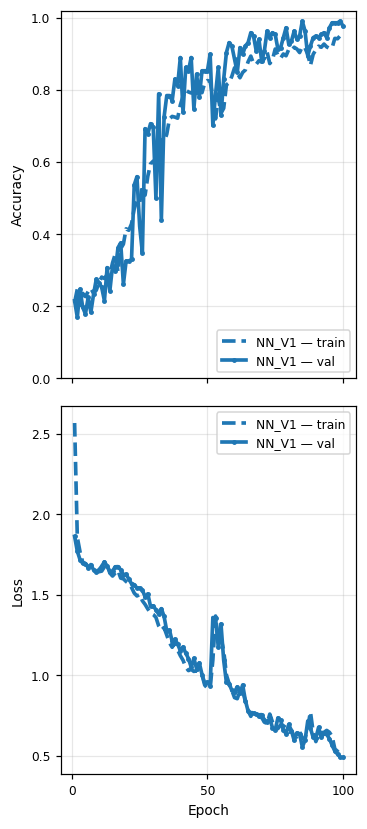

Saved: figs/NN_V2_AccLoss_vertical_single.png and figs/NN_V2_AccLoss_vertical_single.pdf


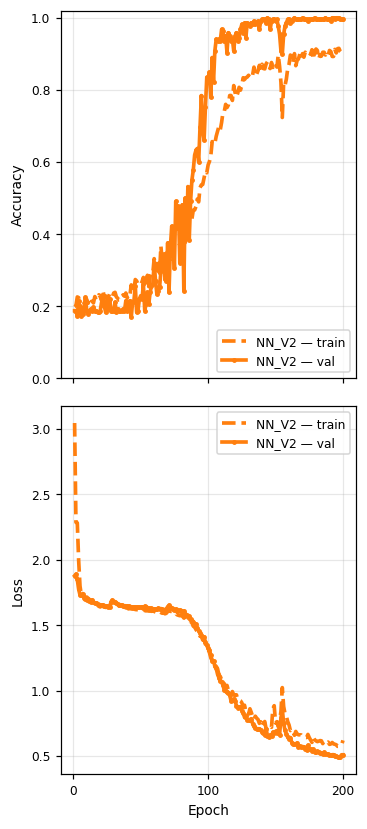

Saved: figs/NN_V3_AccLoss_vertical_single.png and figs/NN_V3_AccLoss_vertical_single.pdf


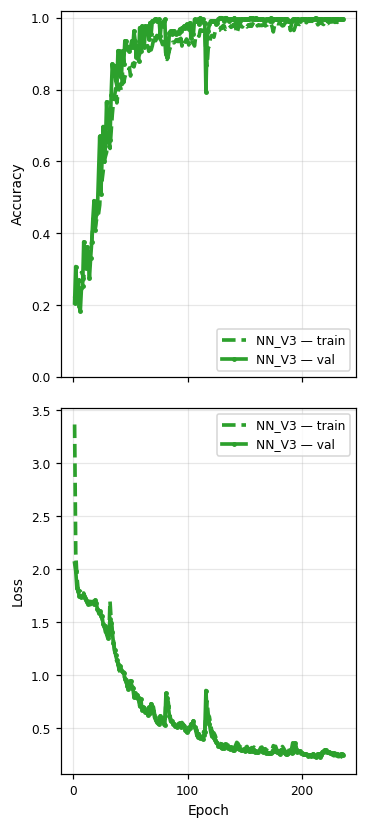

In [19]:
plot_acc_loss_vertical_no_title("NN_V1")  # => figs/NN_V1_AccLoss_vertical_single.(png|pdf)
plot_acc_loss_vertical_no_title("NN_V2")  # => figs/NN_V2_AccLoss_vertical_single.(png|pdf)
plot_acc_loss_vertical_no_title("NN_V3")  # => figs/NN_V3_AccLoss_vertical_single.(png|pdf)

In [20]:
# Traceur vertical Accuracy (haut) + Loss (bas), sans numéro/titre,
# avec couleurs distinctes pour train (clair) et val (foncé).

import os, json, numpy as np, matplotlib.pyplot as plt

SINGLE_COL_W = 3.5  # largeur (inches) pour une colonne

# Paire de couleurs par modèle: train (clair) / val (foncé)
MODEL_PALETTE = {
    "NN_V1": {"train": "#79a8d8", "val": "#1f77b4"},  # bleu clair / bleu
    "NN_V2": {"train": "#f6b26b", "val": "#ff7f0e"},  # orange clair / orange
    "NN_V3": {"train": "#88cc88", "val": "#2ca02c"},  # vert clair / vert
}

def _standardize_history(h):
    if isinstance(h, dict) and "history" in h:
        h = h["history"]
    def pick(d,*ks):
        for k in ks:
            if k in d: return k
        return None
    ak = pick(h,"accuracy","acc")
    vak = pick(h,"val_accuracy","val_acc")
    lk = pick(h,"loss")
    vlk = pick(h,"val_loss")
    if not all([ak,vak,lk,vlk]):
        raise RuntimeError("History must contain accuracy/val_accuracy/loss/val_loss.")
    return {
        "accuracy": np.asarray(h[ak]),
        "val_accuracy": np.asarray(h[vak]),
        "loss": np.asarray(h[lk]),
        "val_loss": np.asarray(h[vlk]),
    }

def _load_npz(path):
    data = np.load(path, allow_pickle=True)
    if set(["accuracy","val_accuracy","loss","val_loss"]).issubset(data.files):
        return {k: data[k] for k in ["accuracy","val_accuracy","loss","val_loss"]}
    if "history" in data.files:
        return _standardize_history(data["history"].item())
    raise RuntimeError(f"Unexpected NPZ keys: {list(data.files)}")

def load_history_for(model_key):
    if "histories" in globals() and model_key in histories:
        return _standardize_history(histories[model_key])
    candidates = []
    if "HISTORY_FILES" in globals() and model_key in HISTORY_FILES:
        candidates += [HISTORY_FILES[model_key]]
    candidates += [
        os.path.join("outputs", model_key, "history.npz"),
        os.path.join("outputs", model_key, "history.json"),
        os.path.join(model_key, "history.npz"),
        os.path.join(model_key, "history.json"),
        "history.npz", "history.json",
    ]
    for p in candidates:
        if p and os.path.isfile(p):
            ext = os.path.splitext(p)[1].lower()
            return _standardize_history(_load_npz(p) if ext==".npz" else json.load(open(p,"r",encoding="utf-8")))
    raise FileNotFoundError(f"No history found for {model_key}. Checked: {candidates}")

def plot_acc_loss_vertical_no_title(model_key, column_width=SINGLE_COL_W, outdir="figs"):
    """Empile Accuracy (haut) + Loss (bas) pour un modèle, sans titre/numéro dans l'image."""
    os.makedirs(outdir, exist_ok=True)
    H = load_history_for(model_key)
    c_train = MODEL_PALETTE.get(model_key, {}).get("train", "#888888")
    c_val   = MODEL_PALETTE.get(model_key, {}).get("val",   "#444444")

    width  = column_width
    height = width * 2.2  # assez haut pour 2 panneaux lisibles

    base = 9  # tailles compatibles colonne simple
    rc_new = {
        "figure.figsize": (width, height),
        "axes.labelsize": base,
        "legend.fontsize": base-1,
        "xtick.labelsize": base-1,
        "ytick.labelsize": base-1,
        "lines.linewidth": 2.4,
        "savefig.dpi": 600,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
    old = {k: plt.rcParams[k] for k in rc_new}
    plt.rcParams.update(rc_new)

    epochs = np.arange(1, len(H["accuracy"])+1)
    fig, axes = plt.subplots(2, 1, sharex=True)

    # Accuracy
    ax = axes[0]
    ax.plot(epochs, H["accuracy"], ls="--", color=c_train, label=f"{model_key} — train")
    ax.plot(epochs, H["val_accuracy"], ls="-", marker="o", markersize=2.2,
            color=c_val, label=f"{model_key} — val")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.0, 1.02)
    ax.legend(loc="lower right", frameon=True)

    # Loss
    ax = axes[1]
    ax.plot(epochs, H["loss"], ls="--", color=c_train, label=f"{model_key} — train")
    ax.plot(epochs, H["val_loss"], ls="-", marker="o", markersize=2.2,
            color=c_val, label=f"{model_key} — val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(loc="upper right", frameon=True)

    fig.tight_layout()
    stem = f"{outdir}/{model_key}_AccLoss_vertical_single"
    plt.savefig(stem + ".png", bbox_inches="tight")
    plt.savefig(stem + ".pdf", bbox_inches="tight")
    print("Saved:", stem + ".png", "and", stem + ".pdf")

    plt.rcParams.update(old)
    plt.show()


Saved: figs/NN_V1_AccLoss_vertical_single.png and figs/NN_V1_AccLoss_vertical_single.pdf


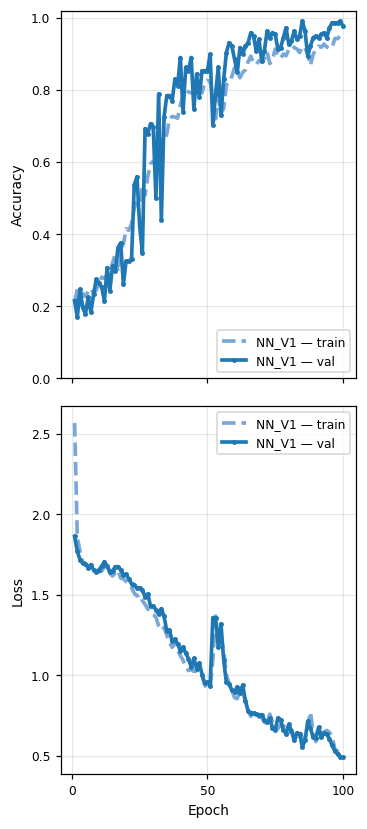

Saved: figs/NN_V2_AccLoss_vertical_single.png and figs/NN_V2_AccLoss_vertical_single.pdf


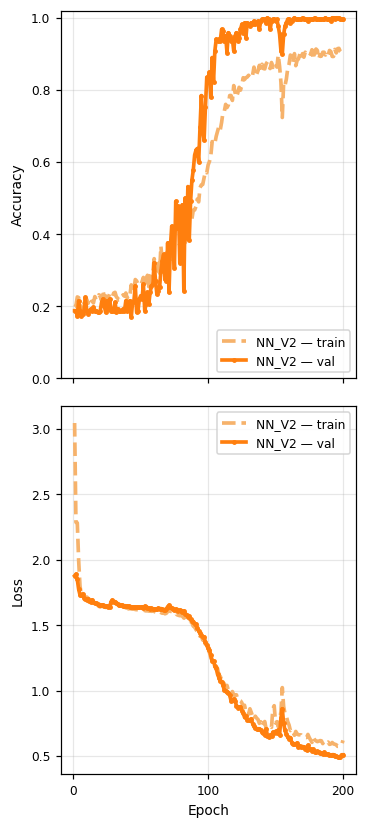

Saved: figs/NN_V3_AccLoss_vertical_single.png and figs/NN_V3_AccLoss_vertical_single.pdf


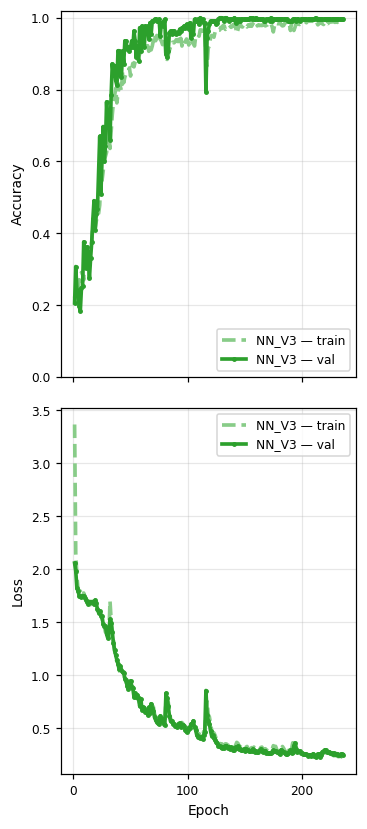

In [21]:
plot_acc_loss_vertical_no_title("NN_V1")  # figs/NN_V1_AccLoss_vertical_single.(png|pdf)
plot_acc_loss_vertical_no_title("NN_V2")  # figs/NN_V2_AccLoss_vertical_single.(png|pdf)
plot_acc_loss_vertical_no_title("NN_V3")  # figs/NN_V3_AccLoss_vertical_single.(png|pdf)


In [22]:
# ==== Traceur vertical (1 colonne) : train gris / val coloré par modèle, sans titre/numéro ====
import os, json, numpy as np, matplotlib.pyplot as plt

# largeur d'une colonne (pouces)
SINGLE_COL_W = 3.5

# Couleur train (fixe) et couleurs val par modèle
TRAIN_COLOR = "#7f7f7f"  # gris neutre
VAL_COLORS = {
    "NN_V1": "#1f77b4",  # bleu
    "NN_V2": "#ff7f0e",  # orange
    "NN_V3": "#2ca02c",  # vert
}

# Si besoin, indique ici les chemins vers les historiques
HISTORY_FILES = {
    "NN_V1": "outputs/NN_V1/history.npz",
    "NN_V2": "outputs/NN_V2/history.npz",
    "NN_V3": "outputs/NN_V3/history.npz",
}

def _standardize_history(h):
    if isinstance(h, dict) and "history" in h:
        h = h["history"]
    def pick(d,*ks):
        for k in ks:
            if k in d: return k
        return None
    ak  = pick(h, "accuracy","acc")
    vak = pick(h, "val_accuracy","val_acc")
    lk  = pick(h, "loss")
    vlk = pick(h, "val_loss")
    if not all([ak, vak, lk, vlk]):
        raise RuntimeError("History missing keys: accuracy/val_accuracy/loss/val_loss.")
    return {
        "accuracy":     np.asarray(h[ak]),
        "val_accuracy": np.asarray(h[vak]),
        "loss":         np.asarray(h[lk]),
        "val_loss":     np.asarray(h[vlk]),
    }

def _load_npz(path):
    data = np.load(path, allow_pickle=True)
    if set(["accuracy","val_accuracy","loss","val_loss"]).issubset(data.files):
        return {k: data[k] for k in ["accuracy","val_accuracy","loss","val_loss"]}
    if "history" in data.files:
        return _standardize_history(data["history"].item())
    raise RuntimeError(f"Unexpected NPZ keys: {list(data.files)}")

def load_history_for(model_key):
    # 1) si un dict 'histories' existe déjà en mémoire
    if "histories" in globals() and model_key in histories:
        return _standardize_history(histories[model_key])
    # 2) sinon, on tente des chemins usuels
    candidates = []
    if model_key in HISTORY_FILES and HISTORY_FILES[model_key]:
        candidates.append(HISTORY_FILES[model_key])
    candidates += [
        os.path.join("outputs", model_key, "history.npz"),
        os.path.join("outputs", model_key, "history.json"),
        os.path.join(model_key, "history.npz"),
        os.path.join(model_key, "history.json"),
        "history.npz", "history.json",
    ]
    for p in candidates:
        if p and os.path.isfile(p):
            ext = os.path.splitext(p)[1].lower()
            return _standardize_history(_load_npz(p) if ext==".npz" else json.load(open(p,"r",encoding="utf-8")))
    raise FileNotFoundError(f"No history found for {model_key}. Checked: {candidates}")

def plot_acc_loss_vertical_two_colors(model_key, column_width=SINGLE_COL_W, outdir="figs"):
    """Empile Accuracy (haut) + Loss (bas), train gris / val coloré, aucune numérotation dans l'image."""
    os.makedirs(outdir, exist_ok=True)
    H = load_history_for(model_key)
    c_train = TRAIN_COLOR
    c_val   = VAL_COLORS.get(model_key, "#1f77b4")

    width  = column_width
    height = width * 2.2  # ratio pour lisibilité 2 panneaux

    base = 9  # tailles adaptées à une colonne
    rc_new = {
        "figure.figsize": (width, height),
        "axes.labelsize": base,
        "legend.fontsize": base-1,
        "xtick.labelsize": base-1,
        "ytick.labelsize": base-1,
        "lines.linewidth": 2.6,
        "savefig.dpi": 600,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
    old = {k: plt.rcParams[k] for k in rc_new}
    plt.rcParams.update(rc_new)

    epochs = np.arange(1, len(H["accuracy"])+1)
    fig, axes = plt.subplots(2, 1, sharex=True)

    # Accuracy
    ax = axes[0]
    ax.plot(epochs, H["accuracy"],     ls="--", color=c_train, label=f"{model_key} — train")
    ax.plot(epochs, H["val_accuracy"], ls="-",  color=c_val,   marker="o", markersize=2.3,
            label=f"{model_key} — val")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.0, 1.02)
    ax.legend(loc="lower right", frameon=True)

    # Loss
    ax = axes[1]
    ax.plot(epochs, H["loss"],     ls="--", color=c_train, label=f"{model_key} — train")
    ax.plot(epochs, H["val_loss"], ls="-",  color=c_val,   marker="o", markersize=2.3,
            label=f"{model_key} — val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(loc="upper right", frameon=True)

    fig.tight_layout()
    stem = f"{outdir}/{model_key}_AccLoss_vertical_twoColors_single"
    plt.savefig(stem + ".png", bbox_inches="tight")
    plt.savefig(stem + ".pdf", bbox_inches="tight")
    print("Saved:", stem + ".png", "and", stem + ".pdf")

    plt.rcParams.update(old)
    plt.show()


Saved: figs/NN_V1_AccLoss_vertical_twoColors_single.png and figs/NN_V1_AccLoss_vertical_twoColors_single.pdf


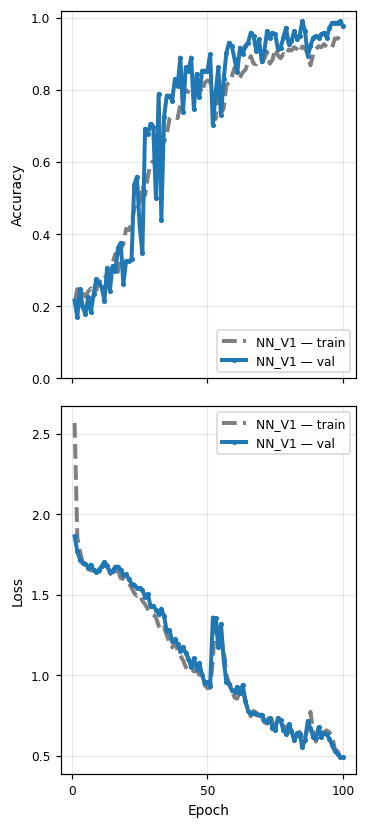

Saved: figs/NN_V2_AccLoss_vertical_twoColors_single.png and figs/NN_V2_AccLoss_vertical_twoColors_single.pdf


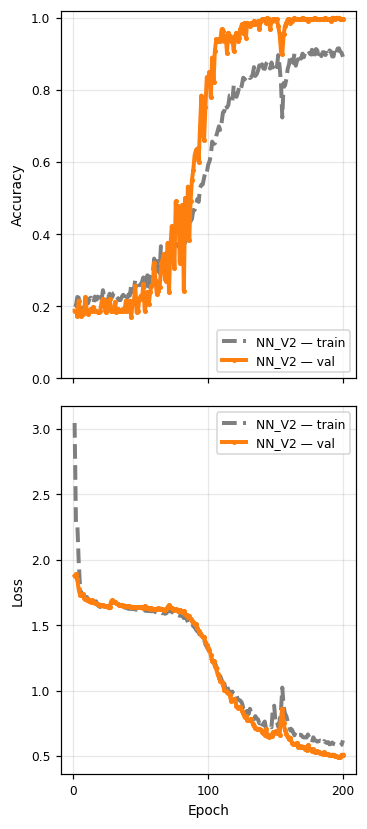

Saved: figs/NN_V3_AccLoss_vertical_twoColors_single.png and figs/NN_V3_AccLoss_vertical_twoColors_single.pdf


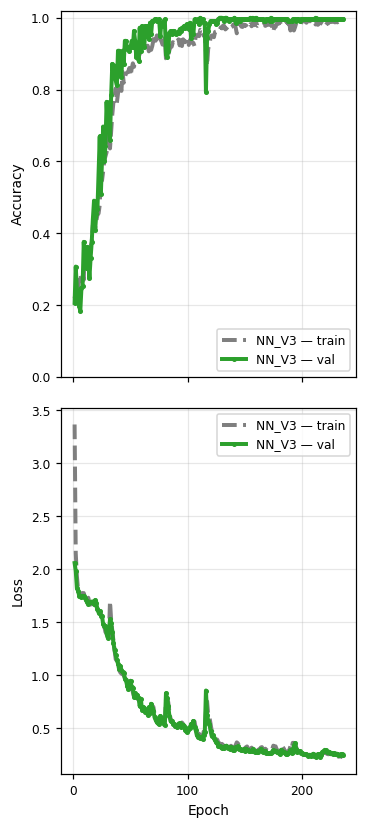

In [23]:
plot_acc_loss_vertical_two_colors("NN_V1")  # figs/NN_V1_AccLoss_vertical_twoColors_single.(png|pdf)
plot_acc_loss_vertical_two_colors("NN_V2")
plot_acc_loss_vertical_two_colors("NN_V3")


In [24]:
# 7.1 (fix) — Export "NN summary" (V1/V2/V3) robuste pour Table 1
import os, json
from pathlib import Path
import numpy as np
import pandas as pd

SEARCH_DIRS = [
    Path("."), Path("./reviewer_pack"), Path("./NN"),
    Path("/spinn_project/NN")
]

def find_latest(patterns, search_dirs=SEARCH_DIRS):
    cands = []
    for d in search_dirs:
        for pat in ([patterns] if isinstance(patterns, str) else patterns):
            cands += list(d.rglob(pat))
    return max(cands, key=lambda p: p.stat().st_mtime) if cands else None

def norm_model_name(s: str) -> str:
    # Uniformise: majuscules + retire espaces/underscores pour matcher "NNV1"
    return "".join(ch for ch in s.upper() if ch.isalnum())

# ---------- charger METRICS ----------
metrics_path = find_latest(["metrics_comparison_rounded*.csv", "metrics_comparison*.csv"])
if metrics_path is None:
    print("[WARN] metrics_comparison*.csv introuvable dans", [str(d) for d in SEARCH_DIRS])
    df_metrics = None
else:
    df_metrics = pd.read_csv(metrics_path)
    print("[INFO] Metrics chargés depuis:", metrics_path)
    print("[INFO] Colonnes métriques:", list(df_metrics.columns))

    # Harmonise nom colonne modèle
    for c in ["model", "Model", "MODEL"]:
        if c in df_metrics.columns:
            df_metrics = df_metrics.rename(columns={c: "Model"})
            break
    if "Model" not in df_metrics.columns:
        # dernière chance: s'il y a une colonne 'name'
        if "name" in df_metrics.columns:
            df_metrics = df_metrics.rename(columns={"name": "Model"})
        else:
            print("[WARN] Colonne du modèle manquante. Valeurs NN seront NaN.")

    # Crée/convertit les 3 colonnes attendues
    def to_pct(colnames, out):
        for c in colnames:
            if c in df_metrics.columns:
                vals = df_metrics[c].astype(float)
                # convertit en % si nécessaire
                if vals.max() <= 1.0:
                    vals = 100.0 * vals
                df_metrics[out] = vals.round(2)
                return True
        return False

    _acc_ok = to_pct(["Val_Accuracy_(%)","val_acc_pct","val_accuracy","val_acc","accuracy"], "Val_Accuracy_(%)")
    _f1_ok  = to_pct(["Macro_F1_(%)","macro_f1_pct","macro_f1"], "Macro_F1_(%)")

    # AUC (garder tel quel si déjà [0,1])
    auc_candidates = ["ROC_AUC_macro","roc_auc_macro","macro_auc","auc_macro"]
    for c in auc_candidates:
        if c in df_metrics.columns:
            auc_vals = df_metrics[c].astype(float)
            # ne pas convertir en % pour AUC macro (on la laisse [0,1])
            df_metrics["ROC_AUC_macro"] = auc_vals.round(3)
            break

    # Normalise clé d'appariement
    if "Model" in df_metrics.columns:
        df_metrics["ModelKey"] = df_metrics["Model"].astype(str).map(norm_model_name)

# ---------- charger FALSE NEGATIVES ----------
fn_path = find_latest(["false_negatives*.csv"])
df_fn = None
if fn_path is not None:
    df_fn = pd.read_csv(fn_path)
    print("[INFO] False negatives chargés depuis:", fn_path)
    # colonnes communes
    for c in ["model","Model","MODEL","name"]:
        if c in df_fn.columns:
            df_fn = df_fn.rename(columns={c:"Model"})
            break
    for c in ["False_Negatives","false_negatives","FN","total_fn"]:
        if c in df_fn.columns:
            df_fn = df_fn.rename(columns={c:"False_Negatives"})
            break
    if "Model" in df_fn.columns:
        df_fn["ModelKey"] = df_fn["Model"].astype(str).map(norm_model_name)
else:
    print("[WARN] false_negatives*.csv introuvable (colonne FN sera NaN).")

# ---------- assembler V1/V2/V3 ----------
want = [("NN V1","NNV1"), ("NN V2","NNV2"), ("NN V3","NNV3")]
rows = []
for disp, key in want:
    rec = {
        "Model": disp,
        "Val_Accuracy_(%)": np.nan,
        "Macro_F1_(%)": np.nan,
        "ROC_AUC_macro": np.nan,
        "False_Negatives": np.nan,
        "Notes": "data-driven"
    }
    if df_metrics is not None and "ModelKey" in df_metrics.columns:
        sub = df_metrics[df_metrics["ModelKey"] == key]
        if len(sub):
            for c in ["Val_Accuracy_(%)","Macro_F1_(%)","ROC_AUC_macro"]:
                if c in sub.columns:
                    rec[c] = sub.iloc[0][c]
    if df_fn is not None and "ModelKey" in df_fn.columns:
        sub = df_fn[df_fn["ModelKey"] == key]
        if len(sub):
            rec["False_Negatives"] = int(sub.iloc[0]["False_Negatives"])
    rows.append(rec)

nn_summary = pd.DataFrame(rows, columns=[
    "Model","Val_Accuracy_(%)","Macro_F1_(%)","ROC_AUC_macro","False_Negatives","Notes"
])

out_dir = Path("reviewer_pack"); out_dir.mkdir(parents=True, exist_ok=True)
csv_path = out_dir / "nn_summary_for_table1.csv"
json_path = out_dir / "nn_summary_for_table1.json"
nn_summary.to_csv(csv_path, index=False)
nn_summary.to_json(json_path, orient="records", indent=2)

print("\n[OK] NN summary écrit ->", csv_path)
display(nn_summary)


[INFO] Metrics chargés depuis: reviewer_pack/metrics_comparison_rounded.csv
[INFO] Colonnes métriques: ['model', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'macro_auc']
[INFO] False negatives chargés depuis: reviewer_pack/false_negatives.csv

[OK] NN summary écrit -> reviewer_pack/nn_summary_for_table1.csv


,Model,Val_Accuracy_(%),Macro_F1_(%),ROC_AUC_macro,False_Negatives,Notes
0,NN V1,98.62,98.6,NaN,0,data-driven
1,NN V2,97.71,97.7,NaN,0,data-driven
2,NN V3,99.54,99.5,NaN,0,data-driven


Saved: figs/NN_V1_AccLoss_horizontal_twoColors_full.png and figs/NN_V1_AccLoss_horizontal_twoColors_full.pdf


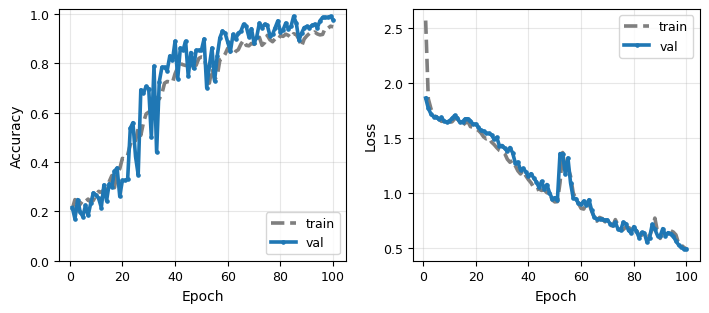

Saved: figs/NN_V2_AccLoss_horizontal_twoColors_full.png and figs/NN_V2_AccLoss_horizontal_twoColors_full.pdf


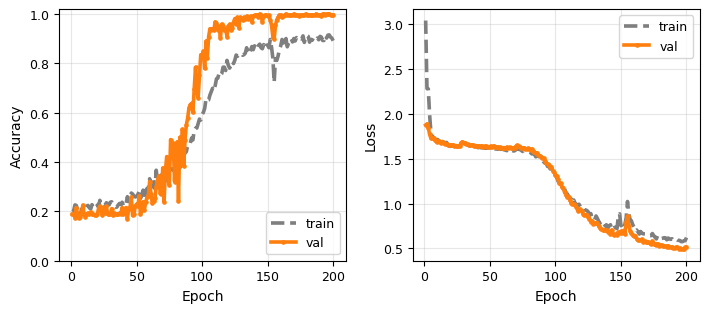

Saved: figs/NN_V3_AccLoss_horizontal_twoColors_full.png and figs/NN_V3_AccLoss_horizontal_twoColors_full.pdf


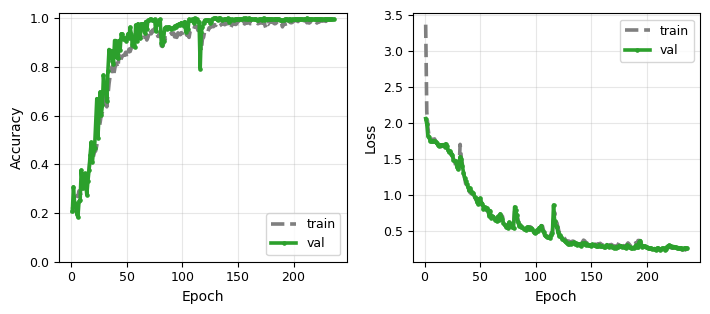

In [1]:
# ==== Traceur horizontal (pleine largeur) : train gris / val coloré par modèle, sans titre/numéro ====
import os, json, numpy as np, matplotlib.pyplot as plt

# largeur "plein texte" Word (approx) ; ajuste si besoin
FULL_PAGE_W = 7.2  # pouces ~ pleine largeur de page/2 colonnes
# Couleur train (fixe) et couleurs val par modèle
TRAIN_COLOR = "#7f7f7f"  # gris neutre
VAL_COLORS = {
    "NN_V1": "#1f77b4",  # bleu
    "NN_V2": "#ff7f0e",  # orange
    "NN_V3": "#2ca02c",  # vert
}

# Chemins usuels des historiques (ajuste si nécessaire)
HISTORY_FILES = {
    "NN_V1": "outputs/NN_V1/history.npz",
    "NN_V2": "outputs/NN_V2/history.npz",
    "NN_V3": "outputs/NN_V3/history.npz",
}

def _standardize_history(h):
    """Retourne un dict avec keys: accuracy, val_accuracy, loss, val_loss (np.array)."""
    if isinstance(h, dict) and "history" in h:
        h = h["history"]
    def pick(d,*ks):
        for k in ks:
            if k in d: return k
        return None
    ak  = pick(h, "accuracy","acc")
    vak = pick(h, "val_accuracy","val_acc")
    lk  = pick(h, "loss")
    vlk = pick(h, "val_loss")
    if not all([ak, vak, lk, vlk]):
        raise RuntimeError("History missing keys: accuracy/val_accuracy/loss/val_loss.")
    return {
        "accuracy":     np.asarray(h[ak]),
        "val_accuracy": np.asarray(h[vak]),
        "loss":         np.asarray(h[lk]),
        "val_loss":     np.asarray(h[vlk]),
    }

def _load_npz(path):
    data = np.load(path, allow_pickle=True)
    if set(["accuracy","val_accuracy","loss","val_loss"]).issubset(data.files):
        return {k: data[k] for k in ["accuracy","val_accuracy","loss","val_loss"]}
    if "history" in data.files:
        return _standardize_history(data["history"].item())
    raise RuntimeError(f"Unexpected NPZ keys: {list(data.files)}")

def load_history_for(model_key):
    # 1) si un dict 'histories' existe déjà en mémoire
    if "histories" in globals() and model_key in histories:
        return _standardize_history(histories[model_key])
    # 2) sinon, essayer différents chemins
    candidates = []
    if model_key in HISTORY_FILES and HISTORY_FILES[model_key]:
        candidates.append(HISTORY_FILES[model_key])
    candidates += [
        os.path.join("outputs", model_key, "history.npz"),
        os.path.join("outputs", model_key, "history.json"),
        os.path.join(model_key, "history.npz"),
        os.path.join(model_key, "history.json"),
        "history.npz", "history.json",
    ]
    for p in candidates:
        if p and os.path.isfile(p):
            ext = os.path.splitext(p)[1].lower()
            return _standardize_history(_load_npz(p) if ext==".npz" else json.load(open(p,"r",encoding="utf-8")))
    raise FileNotFoundError(f"No history found for {model_key}. Checked: {candidates}")

def plot_acc_loss_horizontal_two_colors(model_key, page_width=FULL_PAGE_W, outdir="figs"):
    """
    Deux panneaux côte à côte : Accuracy (gauche) et Loss (droite).
    - Train = gris, Val = couleur propre au modèle.
    - Sans titres/numéros dans l’image ; labels en anglais.
    - Export PNG+PDF haute résolution.
    """
    os.makedirs(outdir, exist_ok=True)
    H = load_history_for(model_key)
    c_train = TRAIN_COLOR
    c_val   = VAL_COLORS.get(model_key, "#1f77b4")

    # Dimensions : plein largeur avec hauteur compacte pour 2 panneaux lisibles
    width  = page_width
    height = width * 0.45  # ratio horizontal

    base = 10  # tailles augmentées pour lisibilité 2 colonnes
    rc_new = {
        "figure.figsize": (width, height),
        "axes.labelsize": base,
        "legend.fontsize": base-1,
        "xtick.labelsize": base-1,
        "ytick.labelsize": base-1,
        "lines.linewidth": 2.6,
        "savefig.dpi": 600,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
    old = {k: plt.rcParams[k] for k in rc_new}
    plt.rcParams.update(rc_new)

    epochs = np.arange(1, len(H["accuracy"])+1)
    fig, axes = plt.subplots(1, 2, sharex=False)

    # --- Accuracy (gauche)
    ax = axes[0]
    ax.plot(epochs, H["accuracy"],     ls="--", color=c_train, label="train")
    ax.plot(epochs, H["val_accuracy"], ls="-",  color=c_val,   marker="o", markersize=2.3, label="val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.0, 1.02)
    ax.legend(loc="lower right", frameon=True)

    # --- Loss (droite)
    ax = axes[1]
    ax.plot(epochs, H["loss"],     ls="--", color=c_train, label="train")
    ax.plot(epochs, H["val_loss"], ls="-",  color=c_val,   marker="o", markersize=2.3, label="val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(loc="upper right", frameon=True)

    fig.tight_layout(w_pad=1.2)
    stem = f"{outdir}/{model_key}_AccLoss_horizontal_twoColors_full"
    plt.savefig(stem + ".png", bbox_inches="tight")
    plt.savefig(stem + ".pdf", bbox_inches="tight")
    print("Saved:", stem + ".png", "and", stem + ".pdf")

    plt.rcParams.update(old)
    plt.show()

# ---- Générer pour chaque modèle
plot_acc_loss_horizontal_two_colors("NN_V1")  # figs/NN_V1_AccLoss_horizontal_twoColors_full.(png|pdf)
plot_acc_loss_horizontal_two_colors("NN_V2")
plot_acc_loss_horizontal_two_colors("NN_V3")
